<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=12>Data Science</font></center>
<center><font size=7>Capstone Supply Chain Management</font></center>
<center><font size=6>Fast Moving Consumer Goods (FMCG) Company</font></center>

## **Problem Statement**

### **Business Context**

A fast-moving consumer goods (FMCG) company that entered the instant noodles market two years ago is facing challenges in balancing demand and supply across its warehouses nationwide. In some regions, demand far exceeds supply, while in others, excess inventory is leading to wastage and higher costs. This mismatch results in significant inventory losses and missed sales opportunities. To remain competitive and profitable in the highly dynamic FMCG sector, the company needs a data-driven approach to optimize its supply chain and align production with regional demand patterns.

### **Objective**

As a data scientist, you are tasked with building a predictive model using historical sales and supply data to determine the optimum quantity of product to ship to each warehouse. Additionally, analyzing demand patterns across different regions will help management design targeted advertisement campaigns. Solving this problem will enable the company to minimize inventory costs, reduce stockouts, and drive higher sales through better demand forecasting and efficient supply chain management.


### **Data Description**



The dataset contains information about the historical sales patterns. The detailed data dictionary is given below:

**Data Dictionary**

- Ware_house_ID: Product warehouse ID

- WH_Manager_ID: Employee ID of warehouse manager

- Location_type: Location of the warehouse, like in a city or a village

- WH_capacity_size: Storage capacity size of the warehouse

- zone: Zone of the warehouse

- WH_regional_zone: Regional zone of the warehouse under each zone

- num_refill_req_l3m: Number of times refilling has been done in the last 3 months

- transport_issue_l1y: Any transport issue, like an accident or goods stolen, reported in the last year

- Competitor_in_mkt: Number of instant noodles competitors in the market

- retail_shop_num: Number of retail shops that sell the product under the warehouse area

- wh_owner_type: Company owns the warehouse, or they have rented the warehouse

- distributor_num: Number of distributors working between the warehouse and retail shops

- flood_impacted: Warehouse is in the flood-impacted area indicator

- flood_proof: Warehouse is flood-proof. Like storage is at some height, not directly on the ground

- electric_supply: The Warehouse has an electric backup, like a generator, so they can run the warehouse in load shedding

- dist_from_hub: Distance between the warehouse to the production hub in Kms

- workers_num: Number of workers working in the warehouse

- wh_est_year: Warehouse established year

- storage_issue_reported_l3m: Warehouse reported a storage issue to the corporate office in the last 3 months. Like rats, fungus due to moisture, etc.

- temp_reg_mach: Warehouse has a temperature regulating machine indicator

- approved_wh_govt_certificate: What kind of standard certificate has been issued to the warehouse from the government regulatory body

- wh_breakdown_l3m: Number of times the warehouse faced a breakdown in the last 3 months. Like a strike by workers, a flood, or an electrical failure

- govt_check_l3m: Number of times government officers have visited the warehouse to check the quality and expiry of stored food in the last 3 months

- product_wg_ton: Product has been shipped in the last 3 months. Weight is in tons

## **Importing necessary libraries and data**

In [269]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# split the data into train and test
from sklearn.model_selection import train_test_split

# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# to build linear regression_model using statsmodels
import statsmodels.api as sm

# to compute VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

# to suppress warnings
import warnings
warnings.filterwarnings("ignore")

# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
    StackingRegressor,
)

from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To tune different models
from sklearn.preprocessing import OrdinalEncoder

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

## **Loading the data**

In [25]:
df = pd.read_csv("supply_chain_data.csv")

In [26]:
# copying data to another variable to avoid any changes to original data
data = df.copy()

## **Data Overview**

### **Displaying the first few rows of the dataset**

In [29]:
data.head()

,Ware_house_ID,WH_Manager_ID,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,...,electric_supply,dist_from_hub,workers_num,wh_est_year,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
0,WH_100000,EID_50000,Urban,Small,West,Zone 6,3,1,2,4651,...,1,91,29.0,NaN,13,0,A,5,15,17115
1,WH_100001,EID_50001,Rural,Large,North,Zone 5,0,0,4,6217,...,1,210,31.0,NaN,4,0,A,3,17,5074
2,WH_100002,EID_50002,Rural,Mid,South,Zone 2,1,0,4,4306,...,0,161,37.0,NaN,17,0,A,6,22,23137
3,WH_100003,EID_50003,Rural,Mid,North,Zone 3,7,4,2,6000,...,0,103,21.0,NaN,17,1,A+,3,27,22115
4,WH_100004,EID_50004,Rural,Large,North,Zone 5,3,1,2,4740,...,1,112,25.0,2009.0,18,0,C,6,24,24071


### **Displaying the last fewrows of the dataset**

In [31]:
data.tail()

,Ware_house_ID,WH_Manager_ID,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,...,electric_supply,dist_from_hub,workers_num,wh_est_year,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
24995,WH_124995,EID_74995,Rural,Small,North,Zone 1,3,0,4,5390,...,1,142,34.0,2005.0,22,1,A,2,30,32093
24996,WH_124996,EID_74996,Rural,Mid,West,Zone 2,6,0,4,4490,...,1,130,28.0,2012.0,10,0,B,4,18,12114
24997,WH_124997,EID_74997,Urban,Large,South,Zone 5,7,0,2,5403,...,1,147,NaN,NaN,23,0,B+,5,25,27080
24998,WH_124998,EID_74998,Rural,Small,North,Zone 1,1,0,2,10562,...,1,60,25.0,NaN,18,0,A,6,30,25093
24999,WH_124999,EID_74999,Rural,Mid,West,Zone 4,8,2,4,5664,...,1,239,39.0,2019.0,4,0,B+,2,11,5058


### **Checking the shape of the dataset**

In [33]:
data.shape

(25000, 24)

**Observations**

- There are 25000 rows and 24 columns in the dataset.

### **Checking the data types of the columns for the dataset**

In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ware_house_ID                 25000 non-null  object 
 1   WH_Manager_ID                 25000 non-null  object 
 2   Location_type                 25000 non-null  object 
 3   WH_capacity_size              25000 non-null  object 
 4   zone                          25000 non-null  object 
 5   WH_regional_zone              25000 non-null  object 
 6   num_refill_req_l3m            25000 non-null  int64  
 7   transport_issue_l1y           25000 non-null  int64  
 8   Competitor_in_mkt             25000 non-null  int64  
 9   retail_shop_num               25000 non-null  int64  
 10  wh_owner_type                 25000 non-null  object 
 11  distributor_num               25000 non-null  int64  
 12  flood_impacted                25000 non-null  int64  
 13  f

**Observations**

- Several identifier and categorical fields (`Ware_house_ID`, `WH_Manager_ID`, `Location_type`, `zone`, `WH_regional_zone`, `wh_owner_type`) are correctly stored as object types.
- Count-based columns (`num_refill_req_l3m`, `Competitor_in_mkt`, `retail_shop_num`, `distributor_num`, `wh_breakdown_l3m`, `govt_check_l3m`, `product_wg_ton`) are correctly stored as integer types.

## Statistical summary of the data

**Let's check the statistical summary of the df.**

In [40]:
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Ware_house_ID,25000,25000,WH_100000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WH_Manager_ID,25000,25000,EID_50000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location_type,25000,2,Rural,22957,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WH_capacity_size,25000,3,Large,10169,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zone,25000,4,North,10278,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WH_regional_zone,25000,6,Zone 6,8339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_refill_req_l3m,25000.0,NaN,NaN,NaN,4.08904,2.606612,0.0,2.0,4.0,6.0,8.0
transport_issue_l1y,25000.0,NaN,NaN,NaN,0.77368,1.199449,0.0,0.0,0.0,1.0,5.0
Competitor_in_mkt,25000.0,NaN,NaN,NaN,3.1042,1.141663,0.0,2.0,3.0,4.0,12.0
retail_shop_num,25000.0,NaN,NaN,NaN,4985.71156,1052.825252,1821.0,4313.0,4859.0,5500.0,11008.0


**Observations**
- Warehouses require refilling about 4 times in the last 3 months on average, while transport issues are relatively infrequent, with most warehouses reporting zero issues in the past year. On average, each market has around 3 competitors, nearly 5,000 retail shops, and about 42 distributors linked to a warehouse.

- Risk and infrastructure indicators show that flood-impacted (≈10%) and flood-proof (≈5%) warehouses are relatively rare. Around 66% of warehouses have electric backup, while only 30% are equipped with temperature-regulating machines. Warehouses are located at an average distance of ~164 km from the production hub.

- In terms of workforce and age, warehouses employ about 29 workers on average, and those with available data were established around 2009. Storage issues are moderately common, with an average of 17 issues reported in the last 3 months, while breakdowns average 3–4 incidents in the same period. Government inspections are frequent, averaging 19 checks in the last 3 months.

- Shipment volumes are substantial, with an average of ~22,100 tons of product shipped in the last 3 months, though the wide range indicates significant variation in warehouse throughput.

## **Data Preprocessing**

### **Checking for unique values**

In [44]:
unique_counts = data.nunique()
unique_counts

Ware_house_ID                   25000
WH_Manager_ID                   25000
Location_type                       2
WH_capacity_size                    3
zone                                4
WH_regional_zone                    6
num_refill_req_l3m                  9
transport_issue_l1y                 6
Competitor_in_mkt                  12
retail_shop_num                  4906
wh_owner_type                       2
distributor_num                    56
flood_impacted                      2
flood_proof                         2
electric_supply                     2
dist_from_hub                     217
workers_num                        60
wh_est_year                        28
storage_issue_reported_l3m         37
temp_reg_mach                       2
approved_wh_govt_certificate        5
wh_breakdown_l3m                    7
govt_check_l3m                     32
product_wg_ton                   4561
dtype: int64

### **Checking for duplicate values**

In [46]:
# checking for duplicate values
df.duplicated().sum()

0

**Observations**
- There is no duplicate value in the data.
- Let's take a closer look at it.

In [48]:
df[df.duplicated(keep=False) == True]

,Ware_house_ID,WH_Manager_ID,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,...,electric_supply,dist_from_hub,workers_num,wh_est_year,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton


**Observations**

- Hence, there are no duplicates present in the data

### **Checking for missing values**

**Before we start exploring the data further, let's quickly check the missing value in the data.**

In [52]:
df.isnull().sum()

Ware_house_ID                       0
WH_Manager_ID                       0
Location_type                       0
WH_capacity_size                    0
zone                                0
WH_regional_zone                    0
num_refill_req_l3m                  0
transport_issue_l1y                 0
Competitor_in_mkt                   0
retail_shop_num                     0
wh_owner_type                       0
distributor_num                     0
flood_impacted                      0
flood_proof                         0
electric_supply                     0
dist_from_hub                       0
workers_num                       990
wh_est_year                     11881
storage_issue_reported_l3m          0
temp_reg_mach                       0
approved_wh_govt_certificate      908
wh_breakdown_l3m                    0
govt_check_l3m                      0
product_wg_ton                      0
dtype: int64

there are missing values in `workers_num`, `wh_est_year`, and `approved_wh_govt_certificate`, we will treat it after EDA

### **Checking for  Anomalous value check**

**Let's check the count of each unique category in each of the categorical variables.**

In [56]:
# Making a list of all catrgorical variables
cat_col = list(df.columns)

# Printing number of count of each unique value in each column
for column in cat_col:
    print(data[column].value_counts())
    print("-" * 50)

Ware_house_ID
WH_100000    1
WH_116650    1
WH_116672    1
WH_116671    1
WH_116670    1
            ..
WH_108331    1
WH_108330    1
WH_108329    1
WH_108328    1
WH_124999    1
Name: count, Length: 25000, dtype: int64
--------------------------------------------------
WH_Manager_ID
EID_50000    1
EID_66650    1
EID_66672    1
EID_66671    1
EID_66670    1
            ..
EID_58331    1
EID_58330    1
EID_58329    1
EID_58328    1
EID_74999    1
Name: count, Length: 25000, dtype: int64
--------------------------------------------------
Location_type
Rural    22957
Urban     2043
Name: count, dtype: int64
--------------------------------------------------
WH_capacity_size
Large    10169
Mid      10020
Small     4811
Name: count, dtype: int64
--------------------------------------------------
zone
North    10278
West      7931
South     6362
East       429
Name: count, dtype: int64
--------------------------------------------------
WH_regional_zone
Zone 6    8339
Zone 5    4587
Zone 4   

**Observations**

- Ware_house_ID and WH_Manager_ID are unique identifiers and should be excluded from analysis.

Warehouses are mostly rural, with large and mid-sized capacities dominating the dataset.

The North zone and Zone 6 contain the highest concentration of warehouses.

Refill demand and market competition are moderate, with most values clustered in mid-ranges.

Most warehouses have electric backup, but flood-proof and temperature-controlled facilities are limited.

Workforce size, breakdowns, inspections, and shipment volumes show high variability, indicating uneven operational scale.


## **Exploratory Data Analysis**

### **Univariate Analysis**

In [60]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

#### **retail_shop_num**

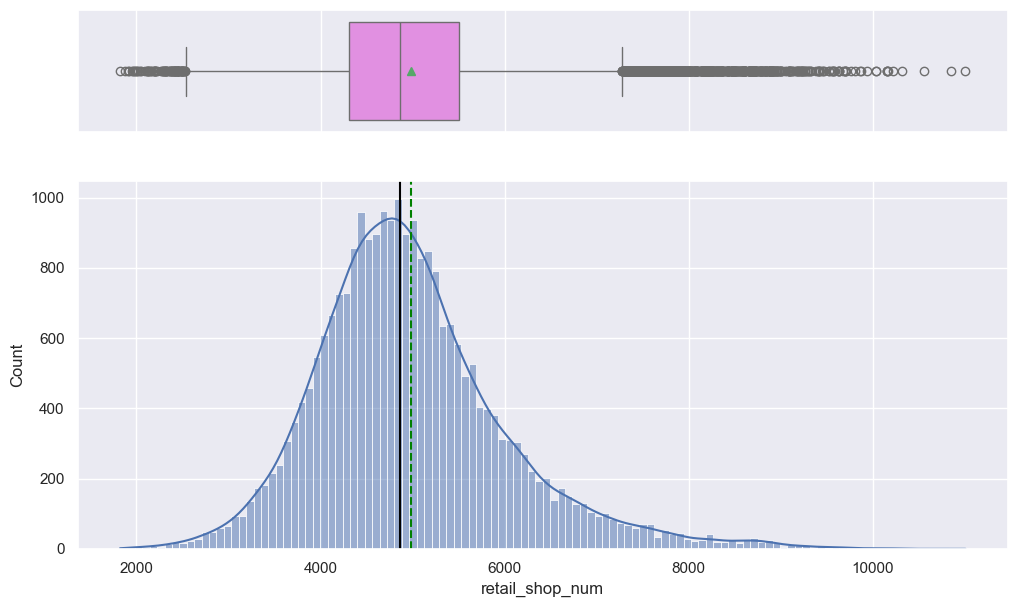

In [64]:
histogram_boxplot(data, "retail_shop_num",kde=True)

**Observations**

* •	The plot shows a kind of normal distribution, and there is a larger number of outliers present

#### **distributor_num**

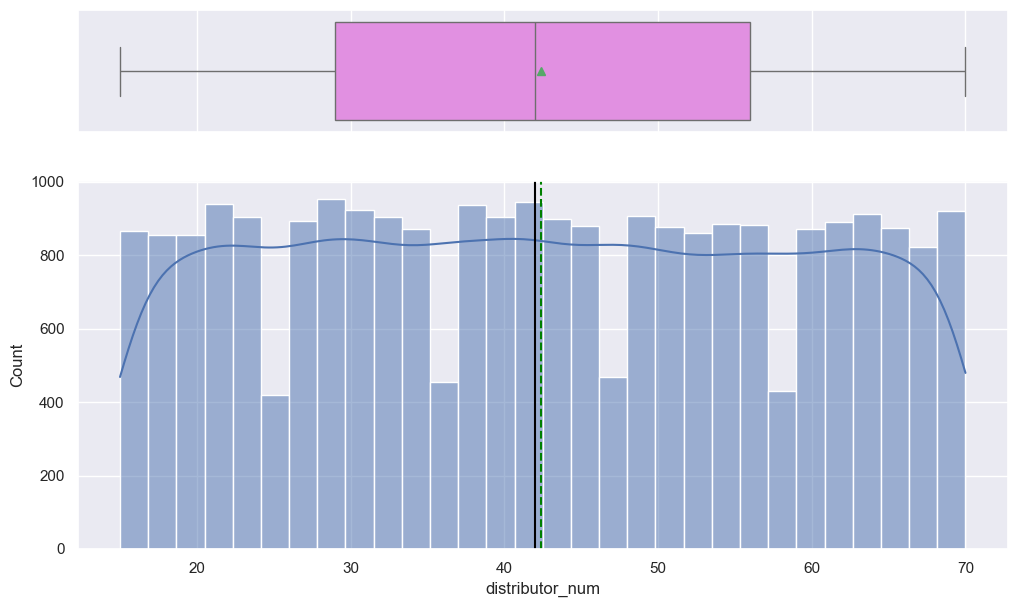

In [67]:
histogram_boxplot(data, "distributor_num", kde=True)

* The number of distributors is evenly distributed across warehouses with no significant skewness or extreme outliers.

#### **product_wg_ton**

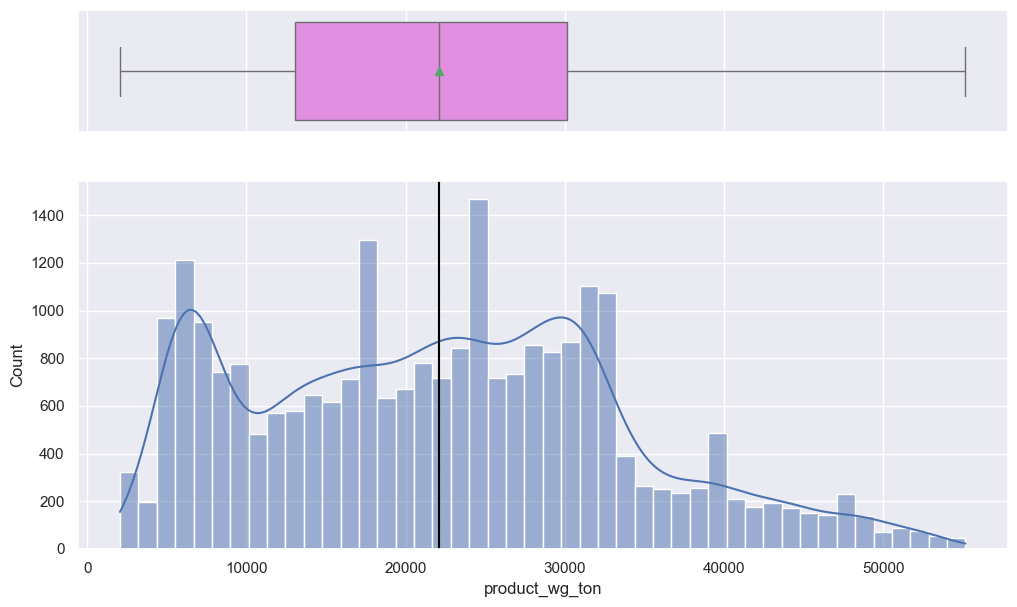

In [70]:
histogram_boxplot(data, "product_wg_ton", kde=True)

**Observations**

* The product_wg_ton distribution is right-skewed with a long tail, indicating most warehouses ship moderate quantities while a few handle very large volumes.

#### **dist_from_hub**

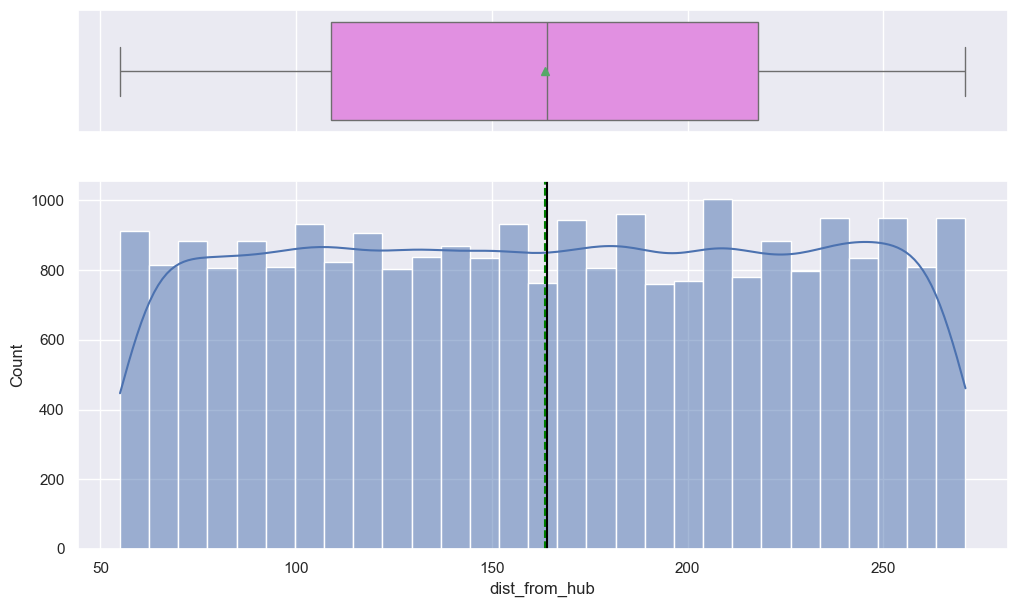

In [73]:
histogram_boxplot(df, "dist_from_hub", kde=True)

**Observations**

* The distance from hub is fairly uniformly distributed across warehouses, with the median near the center and no significant skewness or extreme outliers.

#### **workers_num**

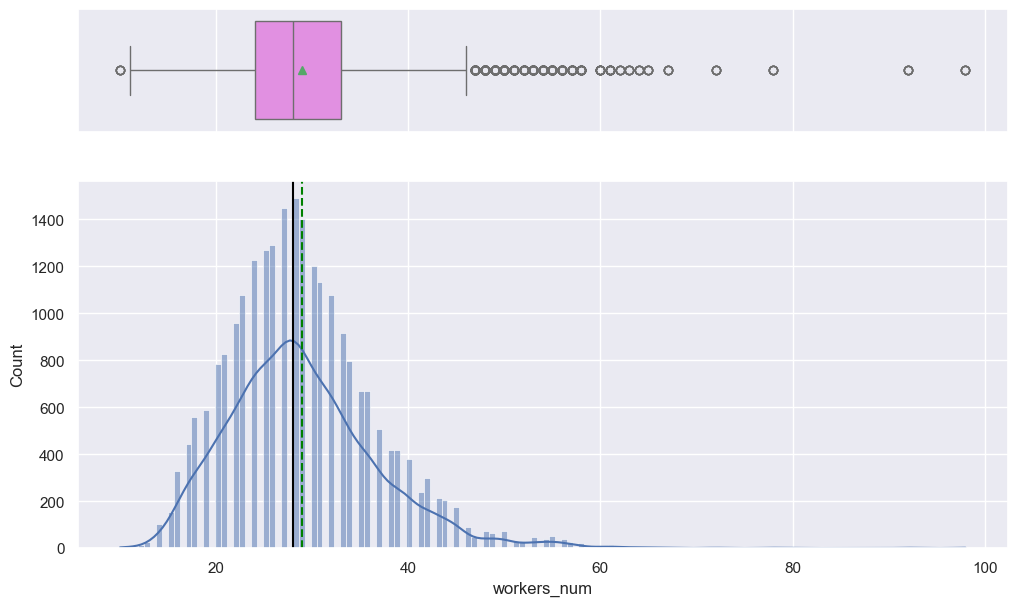

In [76]:
histogram_boxplot(df, "workers_num", kde=True)

**Observations**

* Maruti Swift is the most common car up for resale.

* It is clear from the above charts that our dataset contains used cars from luxury as well as budget-friendly brands.

* We can create a new variable using this information. We can consider binning all our cars into the following 3 categories later:

    1. Budget-Friendly
    2. Mid Range
    3. Luxury Cars

#### **wh_est_year**

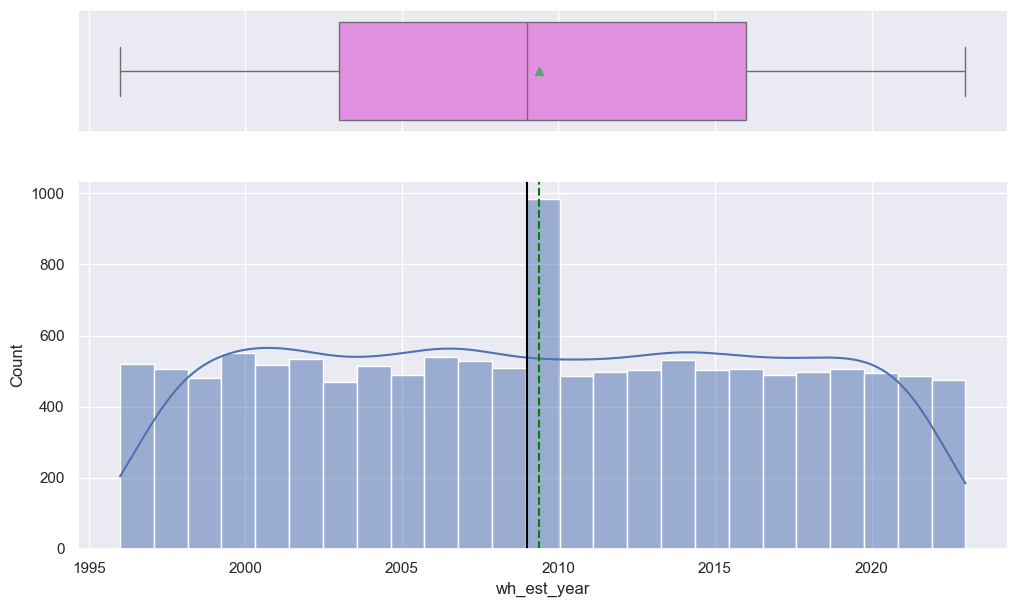

In [79]:
histogram_boxplot(df, "wh_est_year", kde=True)

**Observations**

* The warehouses are fairly evenly distributed across establishment years, with no strong skewness and a median around the late 2000s.

#### **storage_issue_reported_l3m**

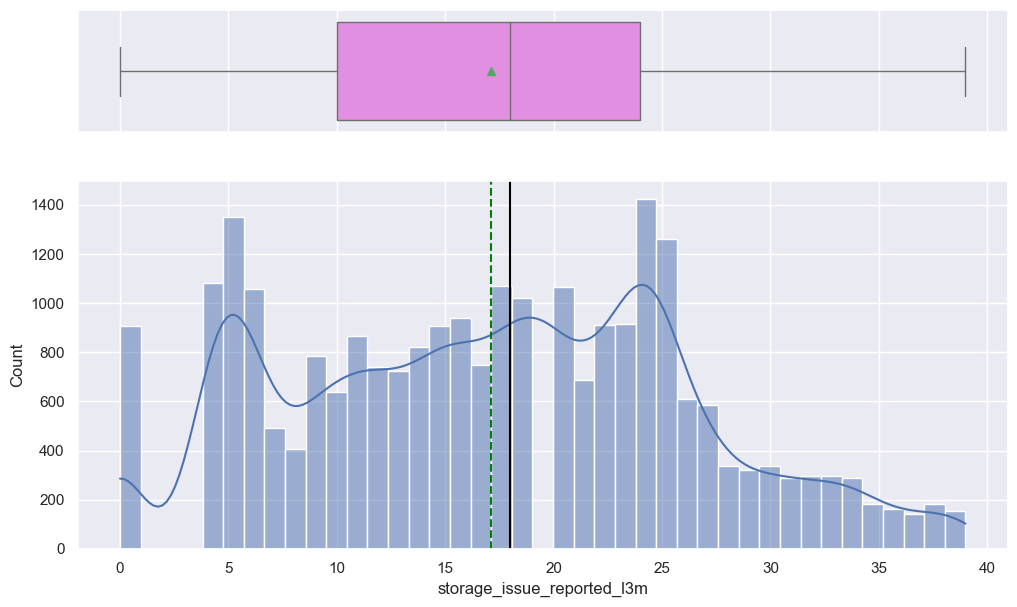

In [82]:
histogram_boxplot(df, "storage_issue_reported_l3m", kde=True)

**Observations**

* The number of storage issues reported in the last three months is moderately right-skewed, with most warehouses reporting lower to mid-range issues and a few experiencing frequent problems.



#### **govt_check_l3m**

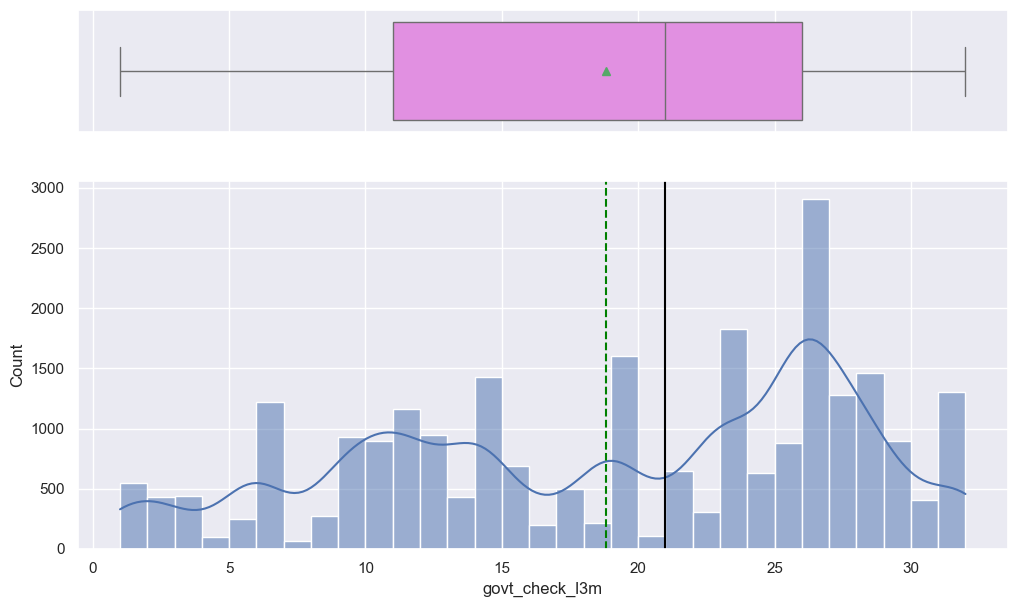

In [85]:
histogram_boxplot(df, "govt_check_l3m", kde=True)

**Observations**

* The frequency of government checks in the last three months shows a slightly right-skewed distribution, with most warehouses experiencing a moderate number of inspections and a few facing very frequent checks.


In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)

    # Use hue to specify the feature for coloring, and legend=False to suppress the legend
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
        legend=False
    )

    for p in ax.patches:
        if perc:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot


#### **Location_type**

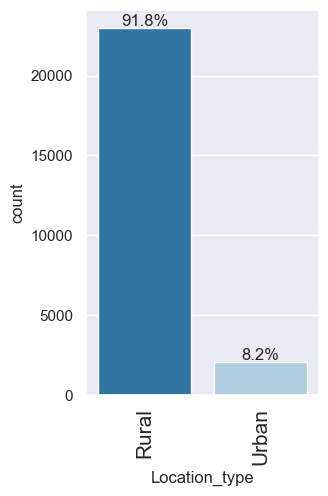

In [89]:
labeled_barplot(data, "Location_type", perc=True)

* •	It observed that 91.8% of dataset have rural in location 

#### **WH_capacity_size**

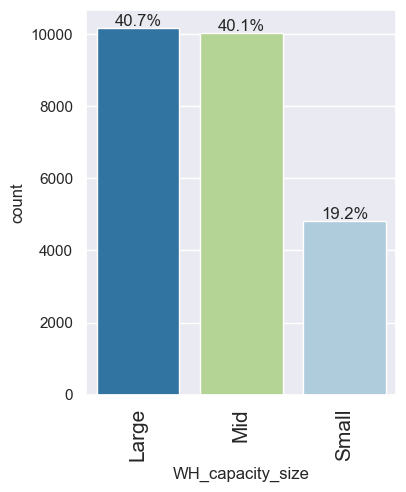

In [92]:

labeled_barplot(data, "WH_capacity_size", perc=True)

**Observations**

* •	It was observed that Large and Mid have approx. 40% capacity

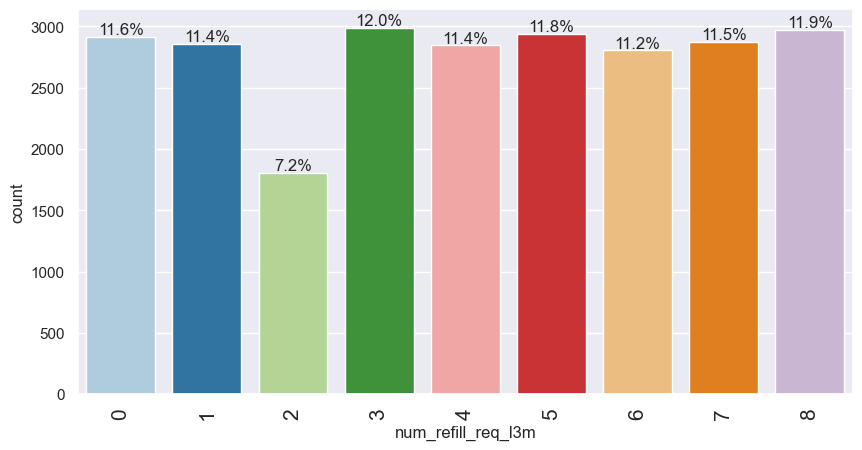

In [94]:
# dropping the redundant columns
labeled_barplot(data, "num_refill_req_l3m", perc=True)

* •	The distribution shows that most of the refill are from 3, which is approx. 12%

#### **transport_issue_l1y**

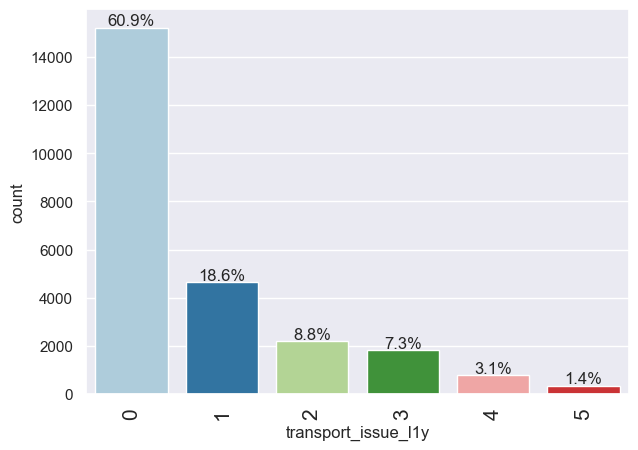

In [97]:

labeled_barplot(data, "transport_issue_l1y", perc=True)

**Observations**

* •	It was observed that 0 has approx. 60% transport issues. 

#### **Competitor_in_mkt**

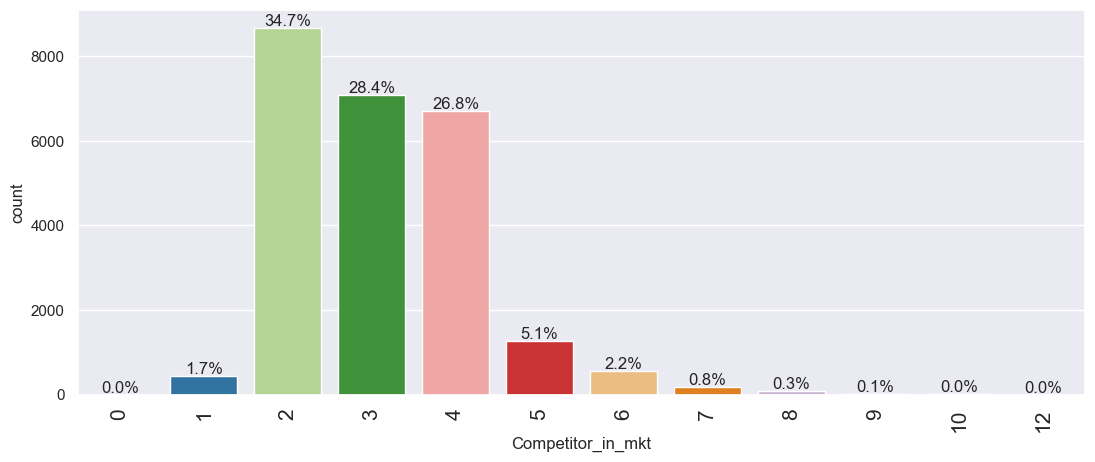

In [100]:

labeled_barplot(data, "Competitor_in_mkt", perc=True)

In [101]:
data['Competitor_in_mkt'].value_counts()


Competitor_in_mkt
2     8669
3     7094
4     6708
5     1265
6      546
1      432
7      189
8       76
9       13
10       6
12       1
0        1
Name: count, dtype: int64

**Observations**

* •	It was observed that 2 has lots of competitors, as 0 only has 1

#### **wh_owner_type**

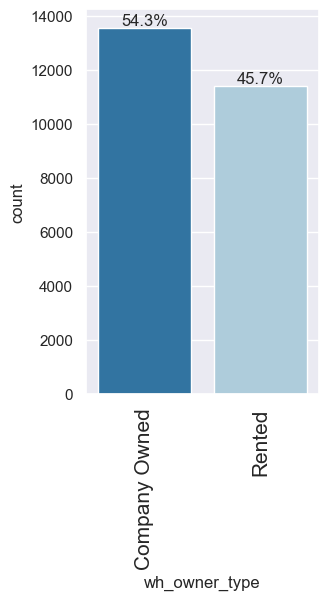

In [104]:

labeled_barplot(data, "wh_owner_type", perc=True)

**Observations**

* •	It observed that company owed has 54% approx. and rented has 45%. 

#### **flood_impacted**

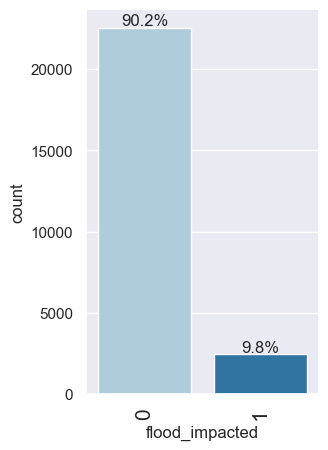

In [107]:

labeled_barplot(data, "flood_impacted", perc=True)

**Observations**

* Maruti Swift is the most common car up for resale.

* It is clear from the above charts that our dataset contains used cars from luxury as well as budget-friendly brands.

* We can create a new variable using this information. We can consider binning all our cars into the following 3 categories later:

    1. Budget-Friendly
    2. Mid Range
    3. Luxury Cars

#### **flood_proof**

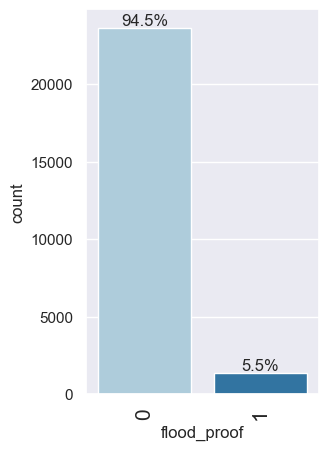

In [110]:

labeled_barplot(data, "flood_proof", perc=True)

**Observations**

* Maruti Swift is the most common car up for resale.

* It is clear from the above charts that our dataset contains used cars from luxury as well as budget-friendly brands.

* We can create a new variable using this information. We can consider binning all our cars into the following 3 categories later:

    1. Budget-Friendly
    2. Mid Range
    3. Luxury Cars

#### **electric_supply**

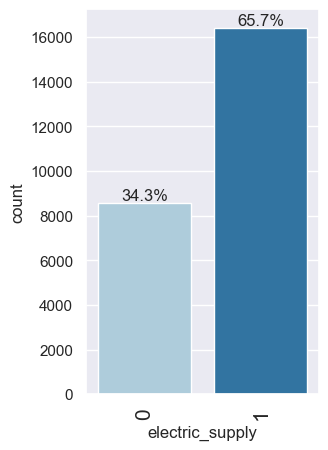

In [113]:

labeled_barplot(data, "electric_supply", perc=True)

**Observations**

* •	It observed that approx. 34% have no electric supply; hence, 65% have. 

#### **temp_reg_mach**

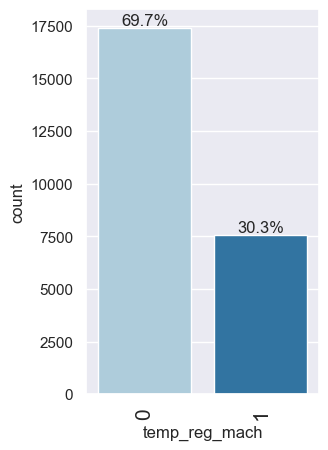

In [116]:

labeled_barplot(data, "temp_reg_mach", perc=True)

**Observations**

* Maruti Swift is the most common car up for resale.

* It is clear from the above charts that our dataset contains used cars from luxury as well as budget-friendly brands.

* We can create a new variable using this information. We can consider binning all our cars into the following 3 categories later:

    1. Budget-Friendly
    2. Mid Range
    3. Luxury Cars

#### **approved_wh_govt_certificate**

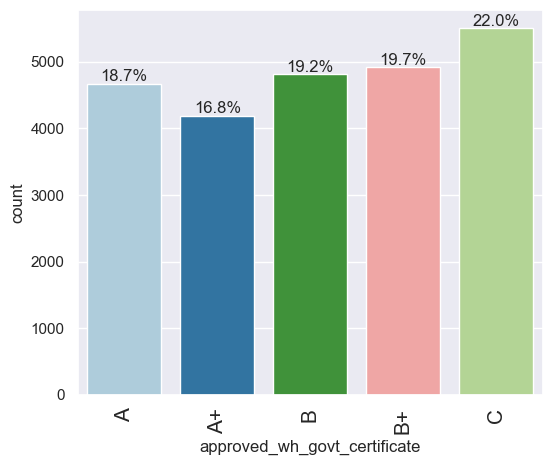

In [119]:

labeled_barplot(data, "approved_wh_govt_certificate", perc=True)

In [120]:
df['approved_wh_govt_certificate'].value_counts()

approved_wh_govt_certificate
C     5501
B+    4917
B     4812
A     4671
A+    4191
Name: count, dtype: int64

**Observations**

* •	It was observed that C certified has a larger amount compared to A+. 
    3. Luxury Cars

#### **wh_breakdown_l3m**

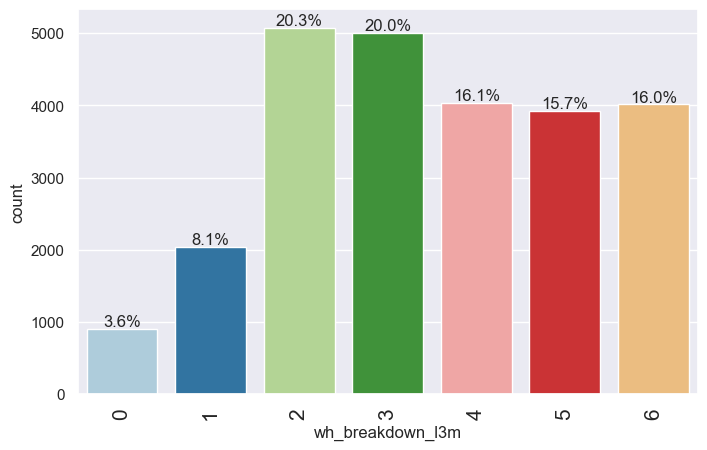

In [123]:

labeled_barplot(data, "wh_breakdown_l3m", perc=True)

**Observations**

* •	It was observed that 2 and 3 have approx. 20% distribution. 

### **Bivariate Distributions**

**Let's check the correlation between numerical variables.**

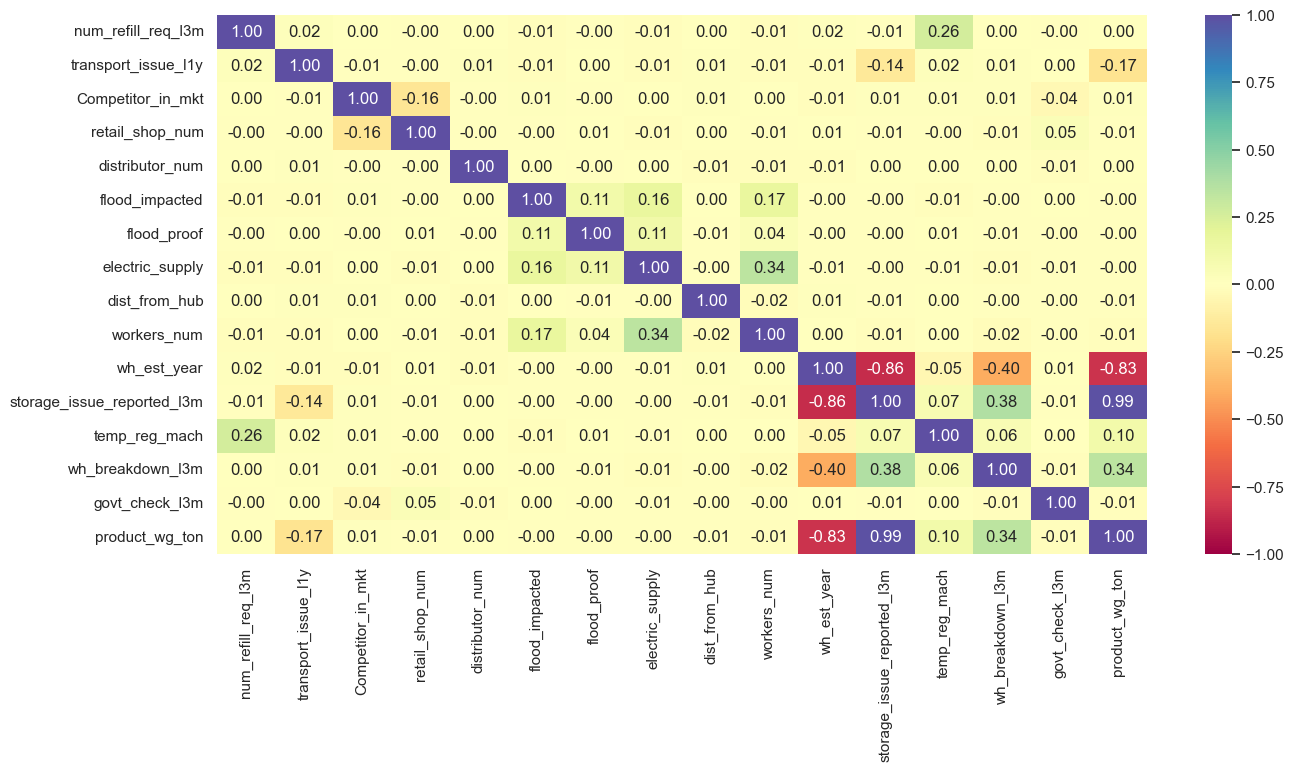

In [127]:
numeric_df = data.select_dtypes(include=[np.number])

plt.figure(figsize=(15, 7))
sns.heatmap(numeric_df.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

**Observations**

* Product shipment volume is tightly linked with storage issues and warehouse breakdowns, indicating higher operational stress at high-throughput warehouses.

Older warehouses tend to handle larger shipment volumes and report more storage-related issues compared to newer facilities.

Infrastructure readiness (electric supply and workforce size) shows moderate alignment, suggesting better-equipped warehouses employ more staff.

Refill frequency has a mild association with temperature-regulating machines, reflecting higher activity levels in controlled-storage facilities.

Market factors (competitors, retail shops, distributors) and external checks (government inspections, flood indicators) show minimal direct correlation with operational performance.

In [61]:
## group wise median analysis 
categorical_cols = [
    'Location_type',
    'WH_capacity_size',
    'wh_owner_type',
    'electric_supply',
    'flood_impacted',
    'flood_proof'
]

for col in categorical_cols:
    print(f"\nGroup-wise statistics for {col}")
    display(
        df.groupby(col)['product_wg_ton']
          .agg(['count', 'mean', 'median'])
          .sort_values(by='median', ascending=False)
    )



Group-wise statistics for Location_type


,count,mean,median
Location_type,,,
Urban,2043,25004.033774,25074.0
Rural,22957,21844.430108,22072.0



Group-wise statistics for WH_capacity_size


,count,mean,median
WH_capacity_size,,,
Mid,10020,22202.298104,22128.5
Large,10169,22100.487855,22093.0
Small,4811,21899.591561,22066.0



Group-wise statistics for wh_owner_type


...

,count,mean,median
electric_supply,,,
1,16422,22084.513884,22105.0
0,8578,22137.320588,22092.0



Group-wise statistics for flood_impacted


,count,mean,median
flood_impacted,,,
0,22546,22111.436707,22103.0
1,2454,22021.748574,22089.5



Group-wise statistics for flood_proof


,count,mean,median
flood_proof,,,
1,1366,22081.318448,22104.0
0,23634,22103.864856,22101.0


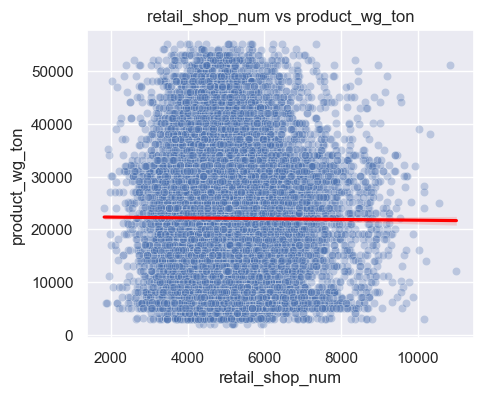

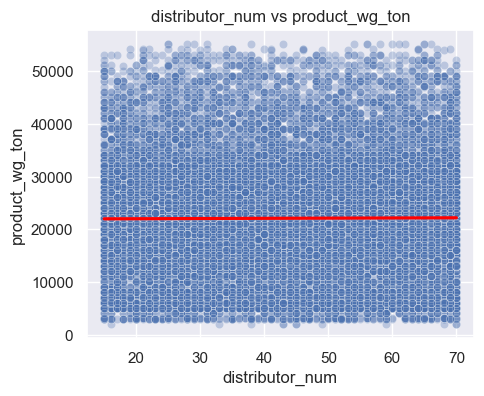

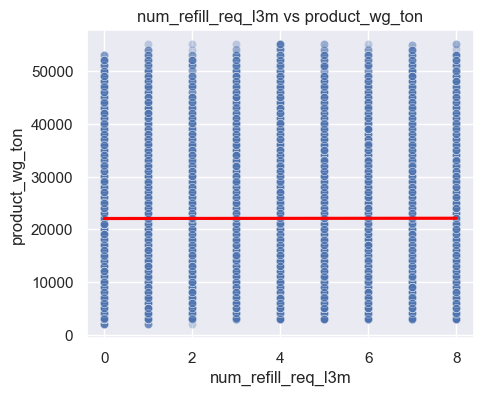

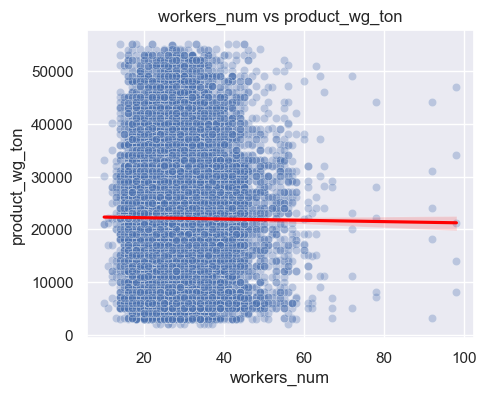

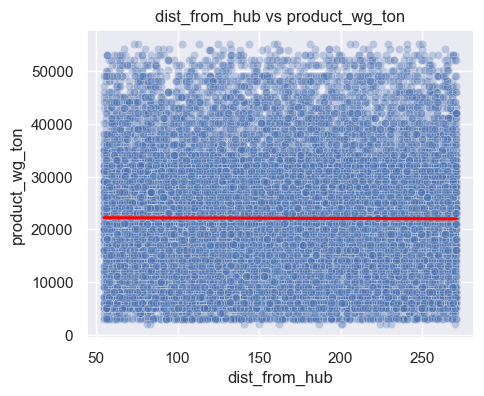

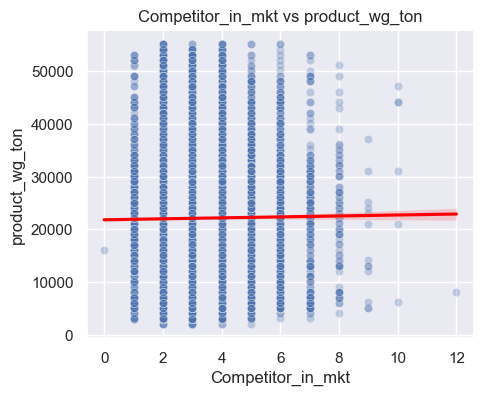

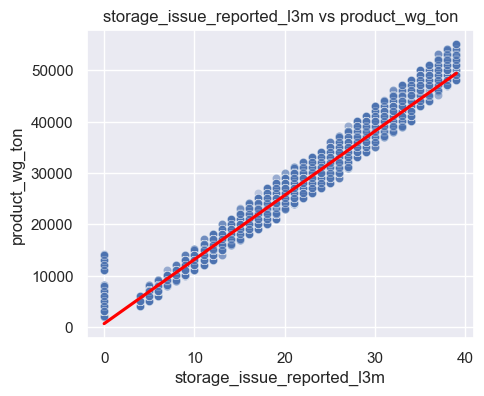

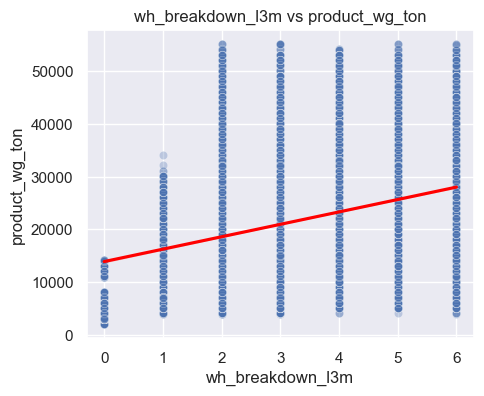

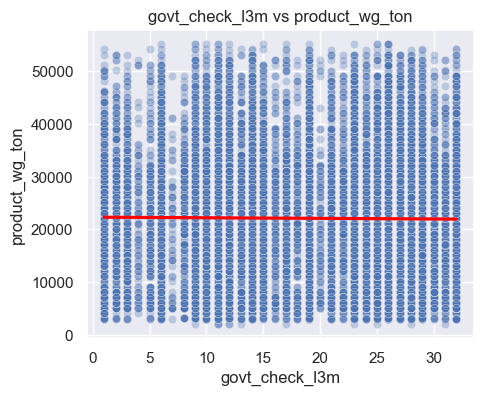

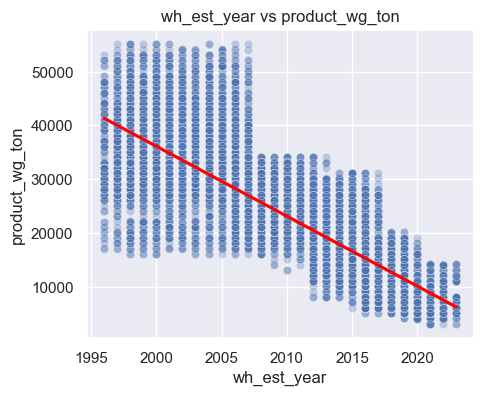

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

num_vars = [
    'retail_shop_num', 'distributor_num', 'num_refill_req_l3m',
    'workers_num', 'dist_from_hub', 'Competitor_in_mkt',
    'storage_issue_reported_l3m', 'wh_breakdown_l3m',
    'govt_check_l3m', 'wh_est_year'
]

for col in num_vars:
    plt.figure(figsize=(5,4))
    sns.scatterplot(x=df[col], y=df['product_wg_ton'], alpha=0.3)
    sns.regplot(x=df[col], y=df['product_wg_ton'], scatter=False, color='red')
    plt.title(f'{col} vs product_wg_ton')
    plt.show()


In [129]:
data.nunique()

Ware_house_ID                   25000
WH_Manager_ID                   25000
Location_type                       2
WH_capacity_size                    3
zone                                4
WH_regional_zone                    6
num_refill_req_l3m                  9
transport_issue_l1y                 6
Competitor_in_mkt                  12
retail_shop_num                  4906
wh_owner_type                       2
distributor_num                    56
flood_impacted                      2
flood_proof                         2
electric_supply                     2
dist_from_hub                     217
workers_num                        60
wh_est_year                        28
storage_issue_reported_l3m         37
temp_reg_mach                       2
approved_wh_govt_certificate        5
wh_breakdown_l3m                    7
govt_check_l3m                     32
product_wg_ton                   4561
dtype: int64

**Let's check the variation in Price with some of the other variables.**

#### **wh_breakdown_l3m vs product_wg_ton**

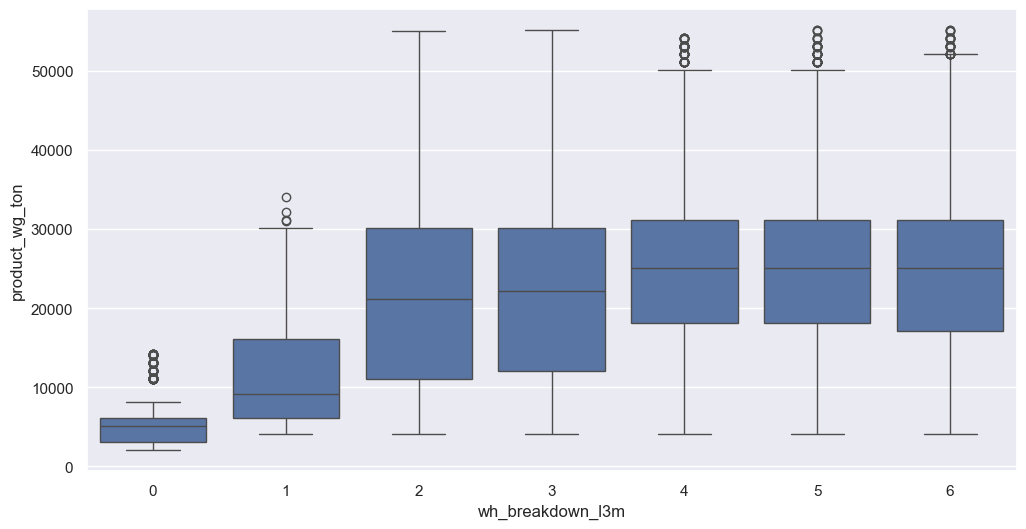

In [132]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="wh_breakdown_l3m", y="product_wg_ton", data=df)
plt.show()

* •	Product shipment volume generally increases with the number of warehouse breakdowns, indicating that higher-activity warehouses tend to experience more breakdown incidents.

#### **storage_issue_reported_l3m vs product_wg_ton**

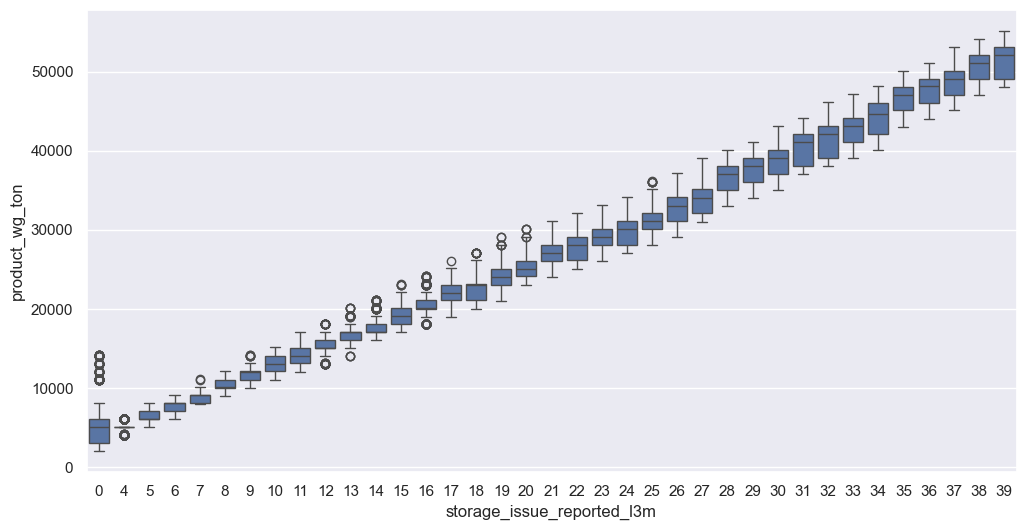

In [135]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="storage_issue_reported_l3m", y="product_wg_ton", data=df)
plt.show()

**Observations**

* Product shipment volume increases steadily with the number of storage issues reported, indicating a strong positive relationship between warehouse activity level and reported storage problems.


#### **product_wg_ton vs wh_est_year**

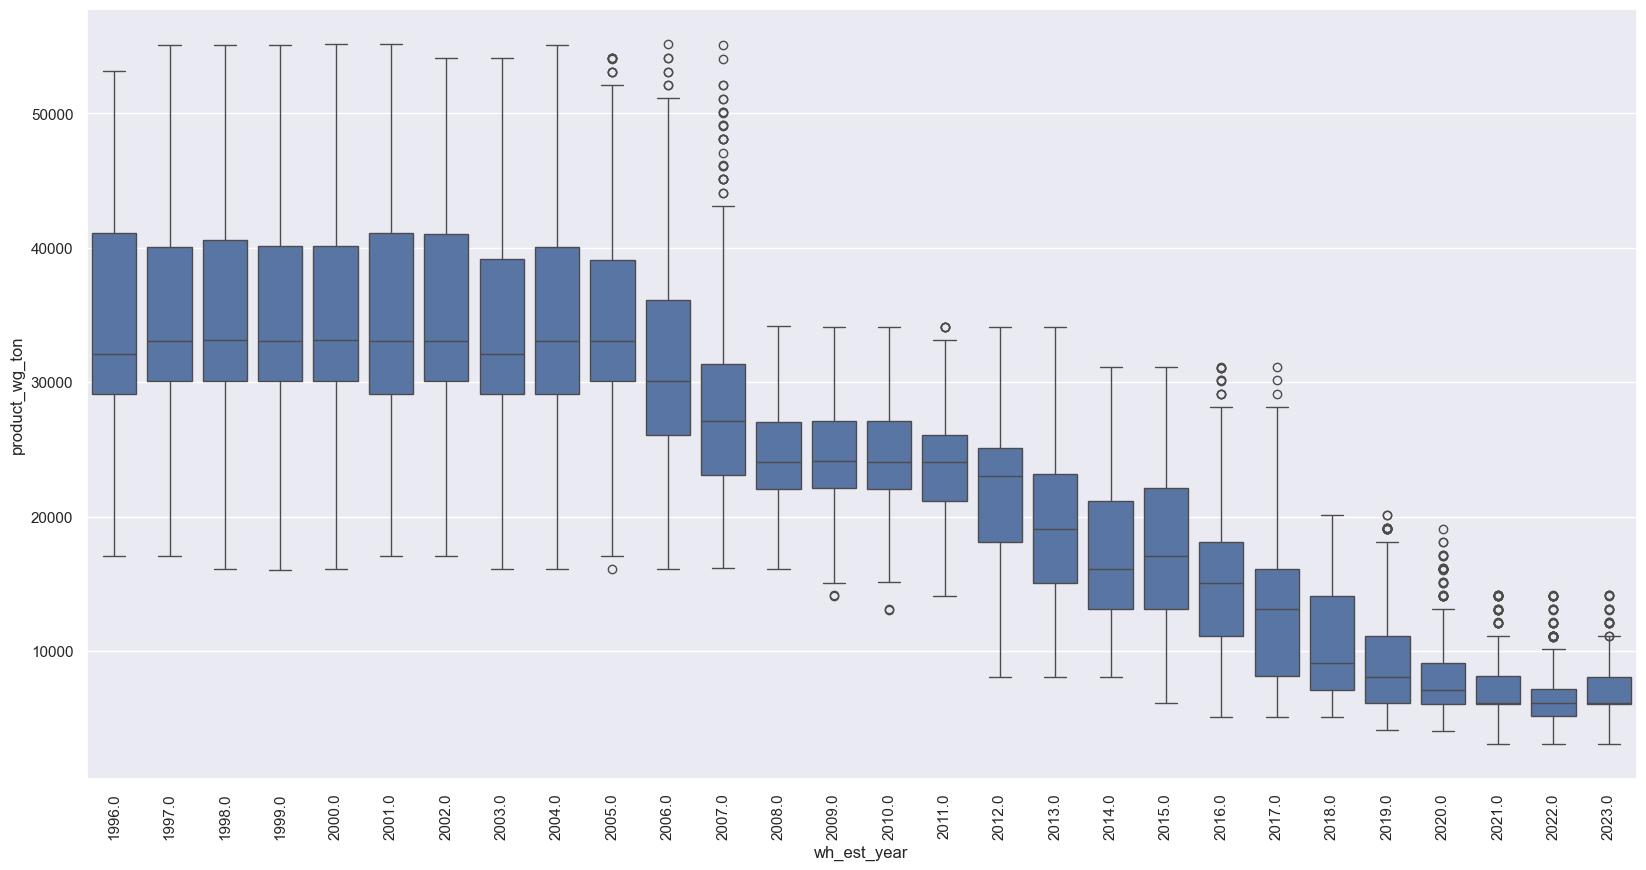

In [138]:
plt.figure(figsize=(20, 10))
sns.boxplot(x="wh_est_year", y="product_wg_ton", data=df)
plt.xticks(rotation=90)

plt.show()

* Product shipment volume tends to be higher for older warehouses and gradually decreases for more recently established warehouses, indicating a negative relationship between establishment year and shipped quantity.


#### **product_wg_ton vs transport_issue_l1y**

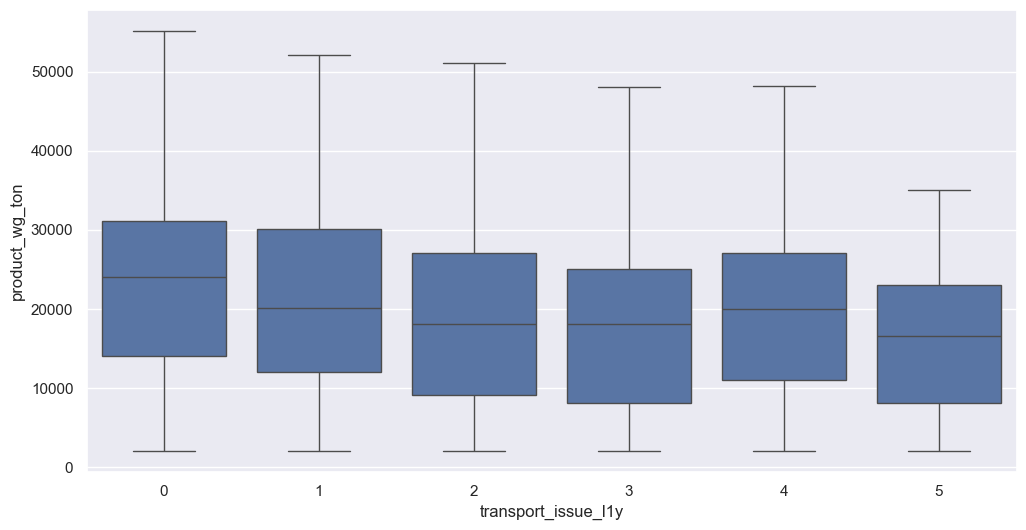

In [141]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="transport_issue_l1y", y="product_wg_ton", data=df)
plt.show()                 

**Observations**

* **product_wg_ton tends to decline as transport_issue_l1y increases, indicating that frequent transport issues negatively impact shipment volumes.**


#### **product_wg_ton vs wh_breakdown_l3m**

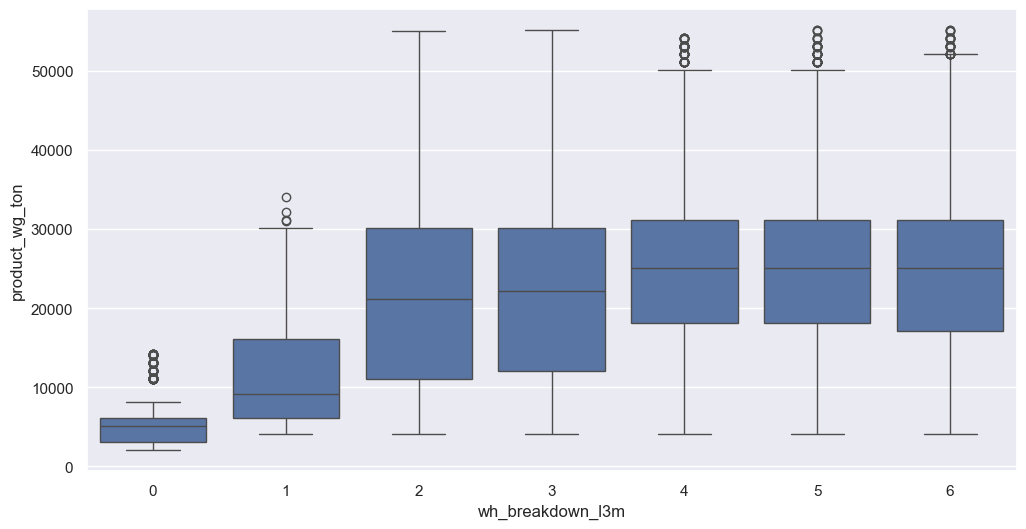

In [144]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="wh_breakdown_l3m", y="product_wg_ton", data=df)
plt.show()                 

**Observations**

* Product shipment volume tends to increase with the number of warehouse breakdowns, indicating a positive relationship between **wh_breakdown_l3m** and **product_wg_ton**.


## **Data Preprocessing (contd.)**

### **Missing value treatment**

In [148]:
# let's check again for missing values
data.isnull().sum()

Ware_house_ID                       0
WH_Manager_ID                       0
Location_type                       0
WH_capacity_size                    0
zone                                0
WH_regional_zone                    0
num_refill_req_l3m                  0
transport_issue_l1y                 0
Competitor_in_mkt                   0
retail_shop_num                     0
wh_owner_type                       0
distributor_num                     0
flood_impacted                      0
flood_proof                         0
electric_supply                     0
dist_from_hub                       0
workers_num                       990
wh_est_year                     11881
storage_issue_reported_l3m          0
temp_reg_mach                       0
approved_wh_govt_certificate      908
wh_breakdown_l3m                    0
govt_check_l3m                      0
product_wg_ton                      0
dtype: int64

**Let's look at a few rows where number of seats is missing.**

In [150]:
df[df["workers_num"].isnull()]

,Ware_house_ID,WH_Manager_ID,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,...,electric_supply,dist_from_hub,workers_num,wh_est_year,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
41,WH_100041,EID_50041,Rural,Small,South,Zone 1,1,0,1,4487,...,1,216,NaN,NaN,25,0,C,5,21,31087
170,WH_100170,EID_50170,Rural,Small,South,Zone 6,4,3,3,8736,...,1,187,NaN,2017.0,6,1,B,5,15,7120
217,WH_100217,EID_50217,Rural,Small,West,Zone 1,4,0,3,5550,...,1,92,NaN,2012.0,19,0,B,4,30,22128
285,WH_100285,EID_50285,Rural,Small,South,Zone 6,4,0,2,4435,...,0,61,NaN,2010.0,18,0,B,4,9,23087
289,WH_100289,EID_50289,Urban,Mid,North,Zone 2,3,0,2,4720,...,1,149,NaN,2004.0,38,0,A,6,12,51140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24962,WH_124962,EID_74962,Rural,Mid,South,Zone 2,4,0,2,4840,...,1,212,NaN,2003.0,19,0,A,5,32,24093
24965,WH_124965,EID_74965,Rural,Small,West,Zone 6,3,0,4,4081,...,1,213,NaN,2008.0,22,0,A,6,9,29096
24968,WH_124968,EID_74968,Rural,Mid,West,Zone 4,5,1,3,5431,...,1,269,NaN,2000.0,26,1,C,3,11,35088
24976,WH_124976,EID_74976,Rural,Large,North,Zone 6,8,4,3,4550,...,0,169,NaN,2009.0,15,1,A+,3,6,20147


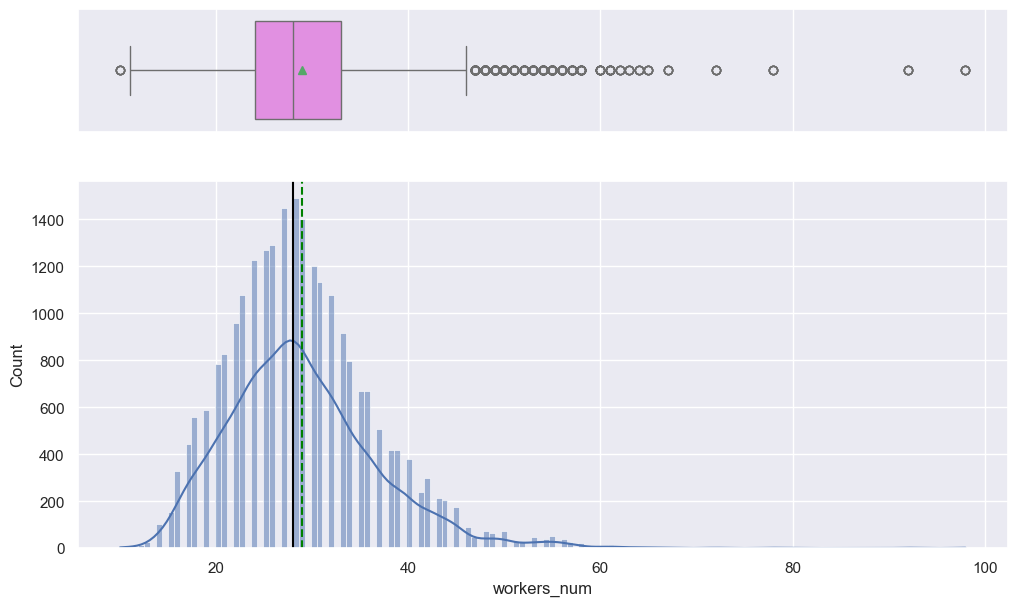

In [151]:
histogram_boxplot(df, "workers_num", kde=True)

In [152]:
df["workers_num"] = df["workers_num"].fillna(df["workers_num"].median())


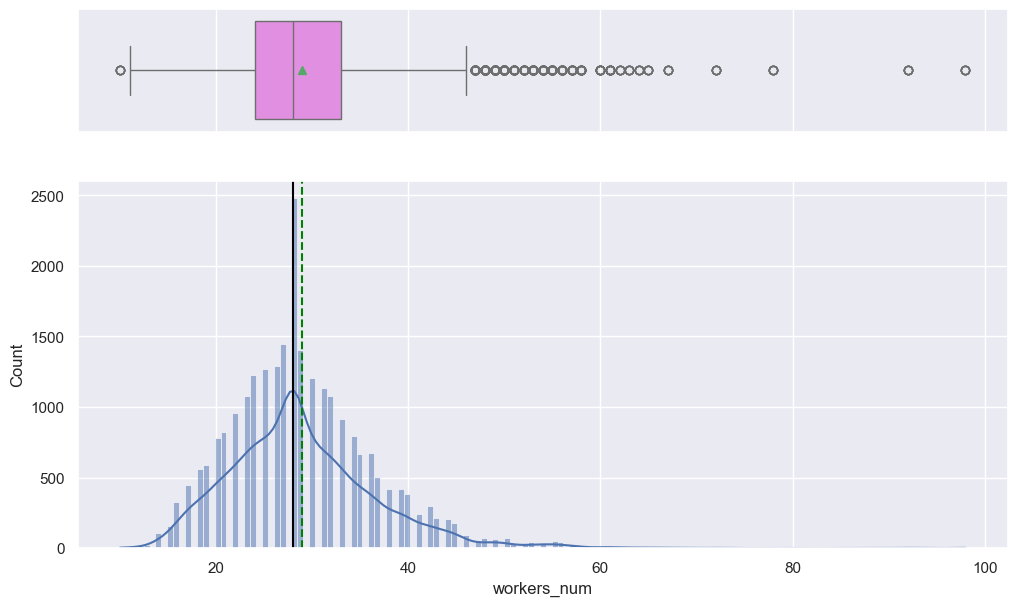

In [153]:
histogram_boxplot(df, "workers_num", kde=True)

In [154]:
# Checking missing values in workers_num
df[df["workers_num"].isnull()]

,Ware_house_ID,WH_Manager_ID,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,...,electric_supply,dist_from_hub,workers_num,wh_est_year,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton


* hence there is no miusiing value in 

**We will use a similar method to fill missing values for the `wh_est_year`, `approved_wh_govt_certificate` columns.**

In [157]:
current_year = 2025  # or max year in data
df['warehouse_age'] = current_year - df['wh_est_year']


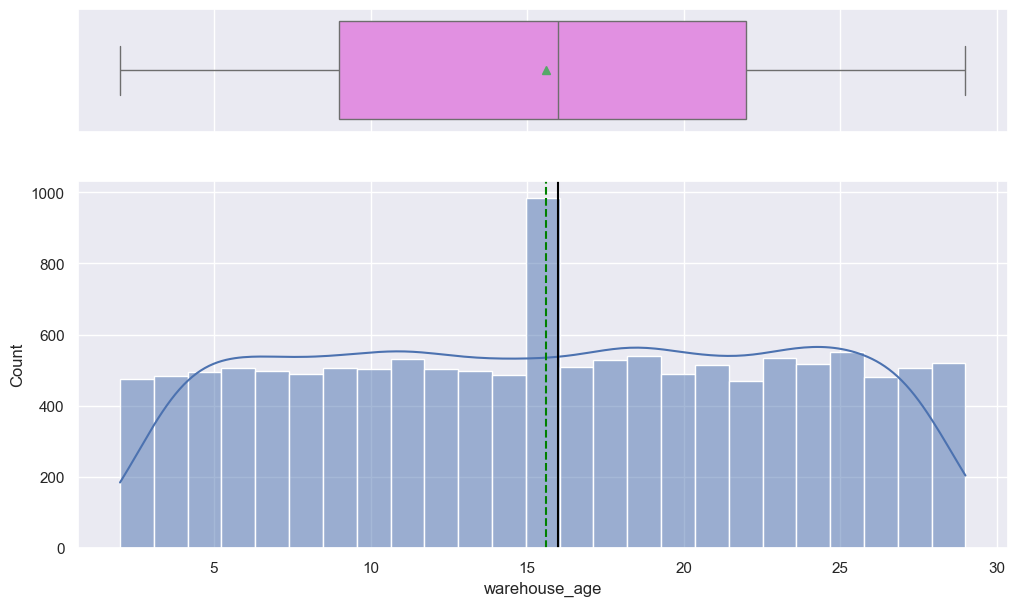

In [158]:
histogram_boxplot(df, "warehouse_age", kde=True)

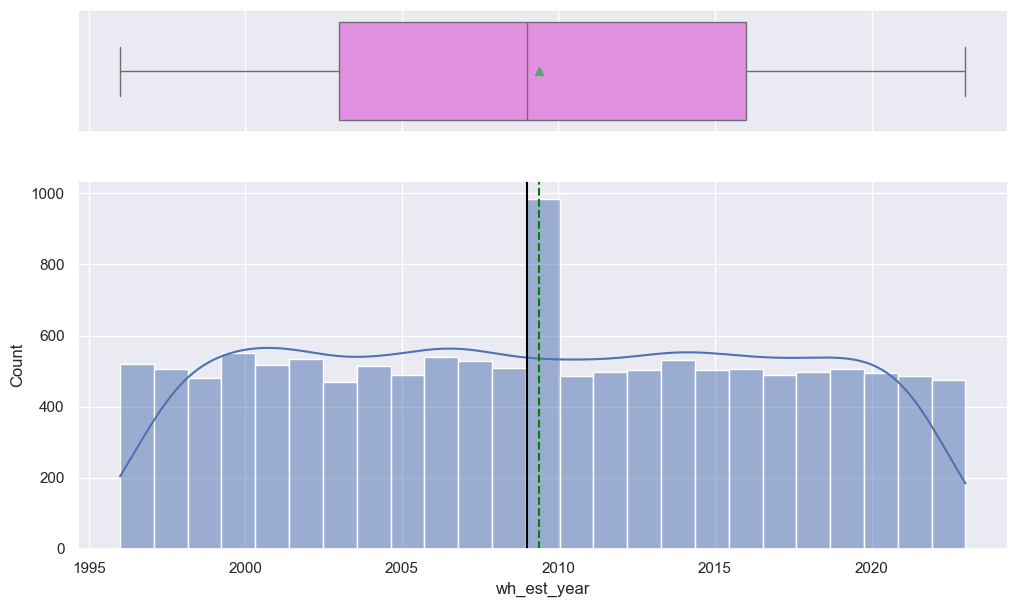

In [159]:
histogram_boxplot(df, "wh_est_year", kde=True)

In [160]:
sig_df = df[['warehouse_age', 'product_wg_ton']].dropna()


In [161]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(
    sig_df['warehouse_age'],
    sig_df['product_wg_ton']
)

corr, p_value


(0.8291182604831975, 0.0)

warehouse age showed a strong and significant association with shipment volume (p < 0.001) and was correlated with multiple capacity and stability indicators, KNN imputation was used to preserve local similarity and structural relationships

In [163]:
df["warehouse_age"].value_counts()

warehouse_age
25.0    551
19.0    541
23.0    533
11.0    531
18.0    528
24.0    518
21.0    515
17.0    509
27.0    507
9.0     507
6.0     507
12.0    502
10.0    502
15.0    499
7.0     498
13.0    497
5.0     496
20.0    489
8.0     488
14.0    486
4.0     485
16.0    485
26.0    482
22.0    469
3.0     332
28.0    329
29.0    191
2.0     142
Name: count, dtype: int64

In [164]:
# checking for missing values in age attribute
df["warehouse_age"].isnull().sum()

11881

KNN imputation was applied to warehouse_age because the variable is numerically continuous and exhibits meaningful relationships with other operational attributes. Unlike mean or median imputation, KNN preserves local similarity by imputing missing values based on comparable warehouses, thereby maintaining structural relationships and improving model reliability.

In [166]:
# we are treating missing values for warehouse age by KNN imputing
from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(n_neighbors=5)

df[['warehouse_age']] = knn_imputer.fit_transform(
    df[['warehouse_age']]
)


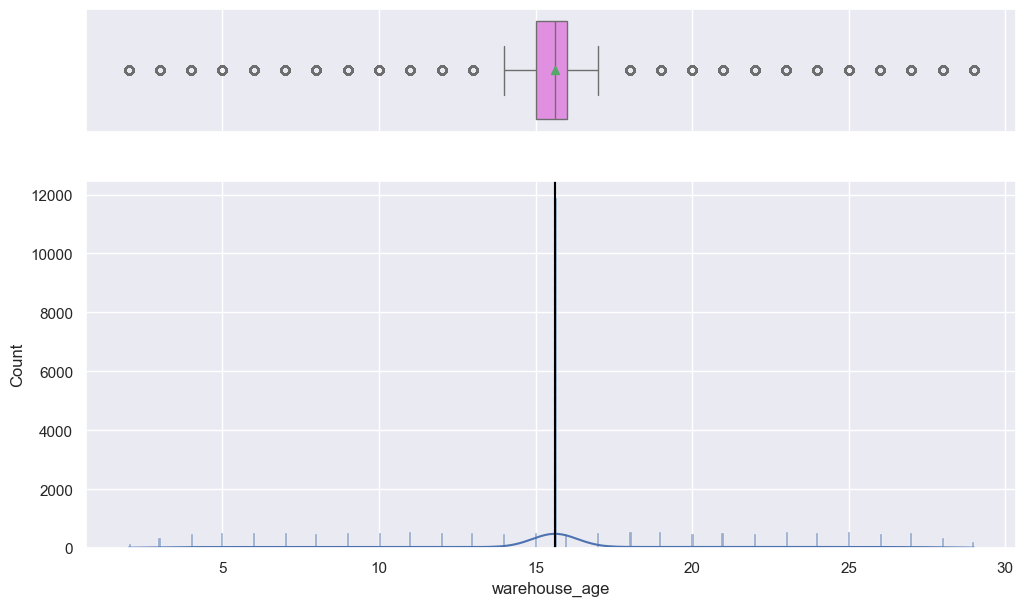

In [167]:
histogram_boxplot(df, "warehouse_age", kde=True)

In [168]:
df["warehouse_age"].value_counts()

warehouse_age
15.616815    11881
25.000000      551
19.000000      541
23.000000      533
11.000000      531
18.000000      528
24.000000      518
21.000000      515
17.000000      509
9.000000       507
27.000000      507
6.000000       507
10.000000      502
12.000000      502
15.000000      499
7.000000       498
13.000000      497
5.000000       496
20.000000      489
8.000000       488
14.000000      486
16.000000      485
4.000000       485
26.000000      482
22.000000      469
3.000000       332
28.000000      329
29.000000      191
2.000000       142
Name: count, dtype: int64

In [169]:
# removing the wh_est_year as it is not use for the modelling and there is warehouse age which will required
df.drop(columns=['wh_est_year'], inplace=True)


**We will use a value mode impute method to fill missing values for the `approved_wh_govt_certificate` columns.**

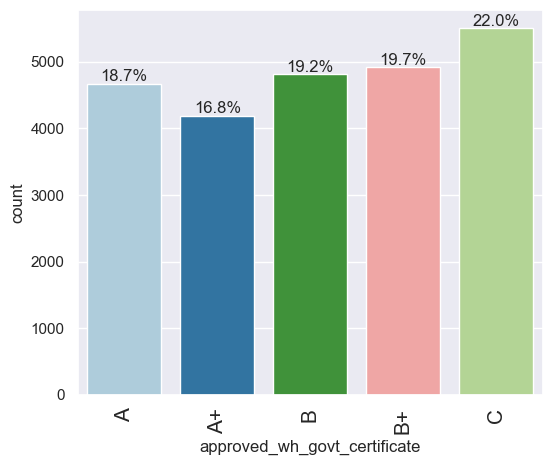

In [171]:
labeled_barplot(df, "approved_wh_govt_certificate", perc=True)

In [172]:
# Impute approved_wh_govt_certificate with 'Not Available'
# df["approved_wh_govt_certificate"] = (
#     df["approved_wh_govt_certificate"]
#     .fillna("Not Available")
# )

mode_value = df['approved_wh_govt_certificate'].mode()[0]
df['approved_wh_govt_certificate'].fillna(mode_value, inplace=True)


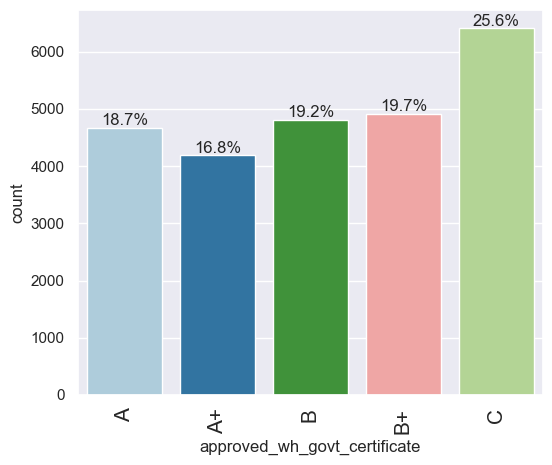

In [173]:
labeled_barplot(df, "approved_wh_govt_certificate", perc=True)

In [174]:
df.isnull().sum()

Ware_house_ID                   0
WH_Manager_ID                   0
Location_type                   0
WH_capacity_size                0
zone                            0
WH_regional_zone                0
num_refill_req_l3m              0
transport_issue_l1y             0
Competitor_in_mkt               0
retail_shop_num                 0
wh_owner_type                   0
distributor_num                 0
flood_impacted                  0
flood_proof                     0
electric_supply                 0
dist_from_hub                   0
workers_num                     0
storage_issue_reported_l3m      0
temp_reg_mach                   0
approved_wh_govt_certificate    0
wh_breakdown_l3m                0
govt_check_l3m                  0
product_wg_ton                  0
warehouse_age                   0
dtype: int64

- All missing values are imputed 

### **Outlier check**

num_refill_req_l3m
transport_issue_l1y
Competitor_in_mkt
retail_shop_num
distributor_num
dist_from_hub
workers_num
warehouse_age
storage_issue_reported_l3m
wh_breakdown_l3m
govt_check_l3m
product_wg_ton


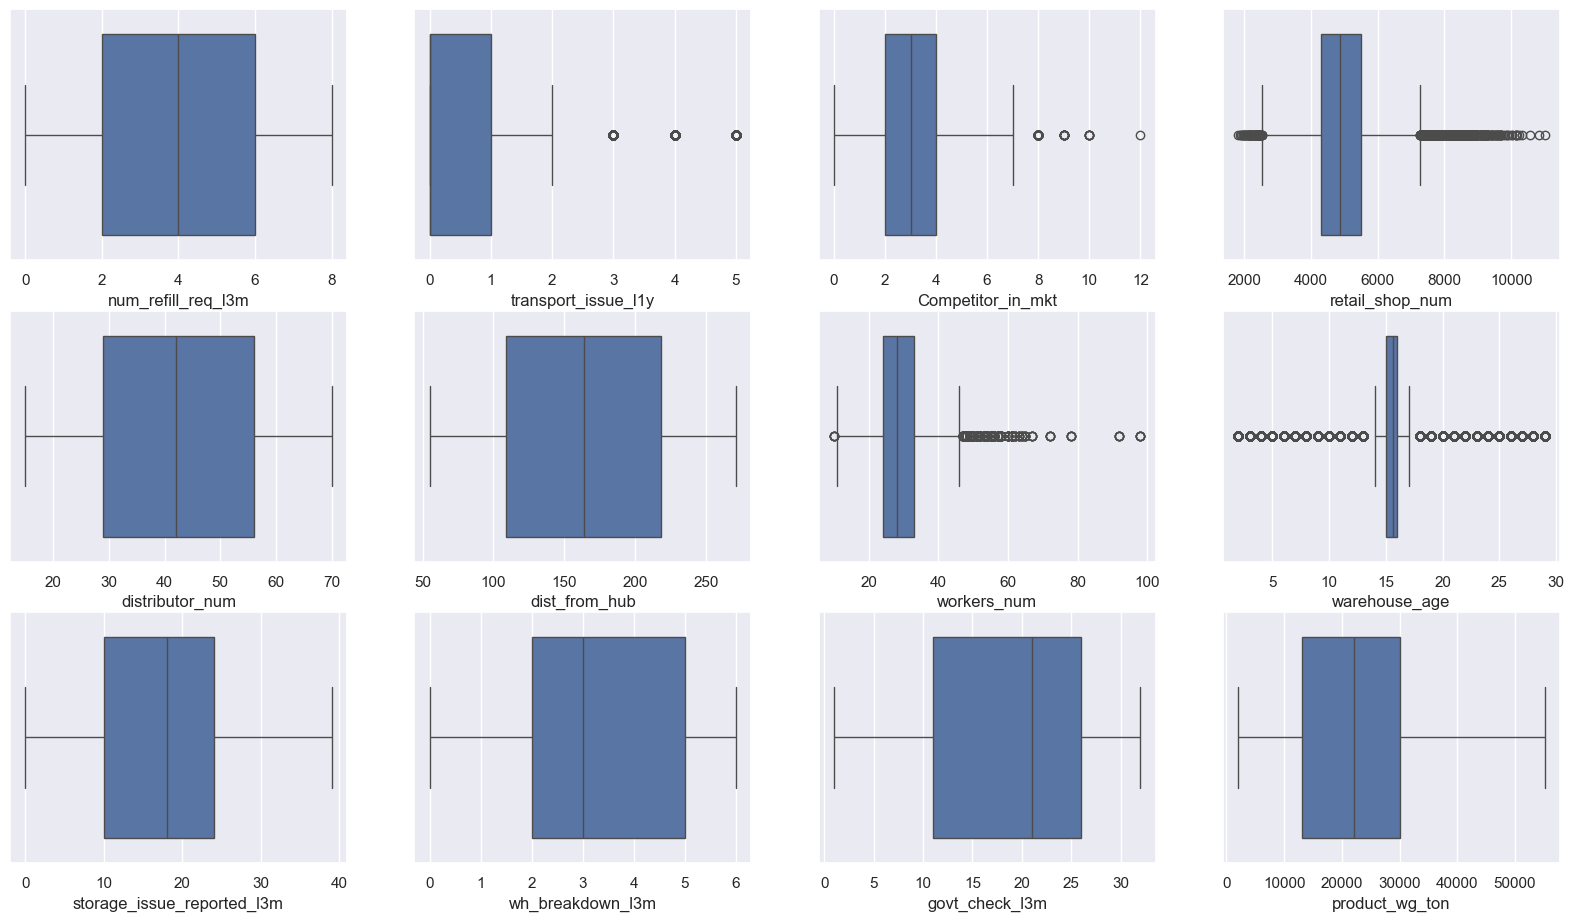

In [178]:
numericcolumns = [
    'num_refill_req_l3m',
    'transport_issue_l1y',
    'Competitor_in_mkt',
    'retail_shop_num',
    'distributor_num',
    'dist_from_hub',
    'workers_num',
    'warehouse_age',
    'storage_issue_reported_l3m',
    'wh_breakdown_l3m',
    'govt_check_l3m',
    'product_wg_ton'
]

plt.figure(figsize=(20, 15))

import seaborn as sns
for i, variable in enumerate(numericcolumns):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(x=df[variable])
    print(variable)
# for i, variable in enumerate(numeric_columns):
#     plt.subplot(4, 4, i + 1)
#     plt.boxplot(data[variable], whis=1.5)
    # plt.tight_layout()
#     plt.title(variable)

plt.show()

# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(20, 15))

# for i, variable in enumerate(numericcolumns):
#     plt.subplot(3, 4, i + 1)
#     sns.boxplot(x=df[variable])
#     plt.title(variable)
#     plt.xlabel('')

# plt.tight_layout()
# plt.show()



- Here, we have lots of outliers in workers_num, retail_shop_num
- We will not treat outliers as they seem relevant to our analysis.

### **DATA PRCOESS FOR MODELLING**

##### **ANOVA**

In [180]:
categorical_cols = [
    'Location_type',
    'WH_capacity_size',
    'zone',
    'WH_regional_zone',
    'wh_owner_type',
    'electric_supply',
    'flood_impacted',
    'flood_proof',
    'temp_reg_mach',
    'approved_wh_govt_certificate'
]

target = 'product_wg_ton'


In [182]:
from scipy.stats import f_oneway

anova_results = {}

for col in categorical_cols:
    
    # Complete-case data for this variable
    sig_test_df = df[[col, target]].dropna()
    
    # Create groups
    groups = [
        sig_test_df[sig_test_df[col] == category][target]
        for category in sig_test_df[col].unique()
    ]
    
    # Keep only groups with data
    groups = [g for g in groups if len(g) > 0]
    
    # ANOVA requires at least 2 groups
    if len(groups) > 1:
        f_stat, p_value = f_oneway(*groups)
        anova_results[col] = p_value
    else:
        anova_results[col] = None


In [184]:
import pandas as pd

anova_df = pd.DataFrame.from_dict(
    anova_results,
    orient='index',
    columns=['p_value']
).reset_index()

anova_df.rename(columns={'index': 'Variable'}, inplace=True)

anova_df['Significant (p < 0.05)'] = anova_df['p_value'].apply(
    lambda x: 'Yes' if x is not None and x < 0.05 else 'No'
)

anova_df



,Variable,p_value,Significant (p < 0.05)
0,Location_type,3.639843e-32,Yes
1,WH_capacity_size,3.310533e-01,No
2,zone,3.453489e-01,No
3,WH_regional_zone,3.339541e-01,No
4,wh_owner_type,3.585434e-01,No
5,electric_supply,7.327428e-01,No
6,flood_impacted,7.162490e-01,No
7,flood_proof,9.443548e-01,No
8,temp_reg_mach,2.126171e-58,Yes
9,approved_wh_govt_certificate,1.550049e-306,Yes


ANOVA results indicate that not all categorical variables significantly differentiate shipment volume. Location type, temperature regulation availability, and government certification status exhibit statistically significant differences in product_wg_ton, highlighting their importance as demand and capacity differentiators. In contrast, variables related to ownership, power backup, flood risk, and regional classification do not show independent statistical significance, suggesting they act as operational or contextual factors rather than direct demand drivers. Accordingly, significant variables were emphasized during feature selection, while non-significant variables were retained selectively to support model stability.

#### We saw encoding requirement in some data for the modelling

In [188]:
print(df['approved_wh_govt_certificate'].value_counts());
print('-'*30);
print(df['Location_type'].value_counts());
print('-'*30);
print(df['wh_owner_type'].value_counts());

approved_wh_govt_certificate
C     6409
B+    4917
B     4812
A     4671
A+    4191
Name: count, dtype: int64
------------------------------
Location_type
Rural    22957
Urban     2043
Name: count, dtype: int64
------------------------------
wh_owner_type
Company Owned    13578
Rented           11422
Name: count, dtype: int64


In [190]:
# Binary categorical encoding
df['Location_type'] = df['Location_type'].map({'Rural': 0, 'Urban': 1})
df['wh_owner_type'] = df['wh_owner_type'].map({'Rented': 0, 'Company Owned': 1})

# Ordinal encoding
wh_capacity_map = {'Small': 1, 'Mid': 2, 'Large': 3}
df['WH_capacity_size'] = df['WH_capacity_size'].map(wh_capacity_map)

certificate_map = {
    'A+': 1,
    'A': 2,
    'B+': 3,
    'B': 4,
    'C': 5,
    'Not Available': 0
}
df['approved_wh_govt_certificate'] = df['approved_wh_govt_certificate'].map(certificate_map)


In [192]:
print(df['approved_wh_govt_certificate'].value_counts());
print('-'*30);
print(df['Location_type'].value_counts());
print('-'*30);
print(df['wh_owner_type'].value_counts());

approved_wh_govt_certificate
5    6409
3    4917
4    4812
2    4671
1    4191
Name: count, dtype: int64
------------------------------
Location_type
0    22957
1     2043
Name: count, dtype: int64
------------------------------
wh_owner_type
1    13578
0    11422
Name: count, dtype: int64


`Hence we processed the data for modelling

In [205]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Ware_house_ID,25000,25000,WH_100000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WH_Manager_ID,25000,25000,EID_50000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location_type,25000.0,NaN,NaN,NaN,0.08172,0.273943,0.0,0.0,0.0,0.0,1.0
WH_capacity_size,25000.0,NaN,NaN,NaN,2.21432,0.743834,1.0,2.0,2.0,3.0,3.0
zone,25000,4,North,10278,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WH_regional_zone,25000,6,Zone 6,8339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_refill_req_l3m,25000.0,NaN,NaN,NaN,4.08904,2.606612,0.0,2.0,4.0,6.0,8.0
transport_issue_l1y,25000.0,NaN,NaN,NaN,0.77368,1.199449,0.0,0.0,0.0,1.0,5.0
Competitor_in_mkt,25000.0,NaN,NaN,NaN,3.1042,1.141663,0.0,2.0,3.0,4.0,12.0
retail_shop_num,25000.0,NaN,NaN,NaN,4985.71156,1052.825252,1821.0,4313.0,4859.0,5500.0,11008.0


In [208]:
df = df.drop(columns=['Ware_house_ID', 'WH_Manager_ID'])


### Data Scaling 

In [244]:
nominal_cols = ['approved_wh_govt_certificate',
    'zone',
    'WH_regional_zone']

ordinal_cols = ['WH_capacity_size']

binary_cols = ['Location_type',
    'wh_owner_type',
    'flood_impacted',
    'flood_proof',
    'electric_supply',
    'temp_reg_mach']

numeric_cols = ['num_refill_req_l3m',
    'transport_issue_l1y',
    'Competitor_in_mkt',
    'retail_shop_num',
    'distributor_num',
    'dist_from_hub',
    'workers_num',
    'warehouse_age',
    'storage_issue_reported_l3m',
    'wh_breakdown_l3m',
    'govt_check_l3m']


In [246]:
# from sklearn.model_selection import train_test_split

X = df.drop(columns=['product_wg_ton'])
y = df['product_wg_ton']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [248]:
X_train.shape, X_test.shape

((17500, 21), (7500, 21))

In [252]:
# Label Encode
# from sklearn.preprocessing import OrdinalEncoder

ord_encoder = OrdinalEncoder()
X_train[ordinal_cols] = ord_encoder.fit_transform(X_train[ordinal_cols])
X_test[ordinal_cols] = ord_encoder.transform(X_test[ordinal_cols])


In [254]:
X_train = pd.get_dummies(X_train, columns=nominal_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=nominal_cols, drop_first=True)

# Align train and test columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


In [256]:
# from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


In [258]:
X_train.shape, X_test.shape

((17500, 30), (7500, 30))

In [260]:
X_train.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Location_type,17500.0,NaN,NaN,NaN,0.082171,0.274634,0.0,0.0,0.0,0.0,1.0
WH_capacity_size,17500.0,NaN,NaN,NaN,1.217371,0.742801,0.0,1.0,1.0,2.0,2.0
num_refill_req_l3m,17500.0,NaN,NaN,NaN,-0.0,1.000029,-1.567462,-0.800516,-0.03357,0.733376,1.500322
transport_issue_l1y,17500.0,NaN,NaN,NaN,-0.0,1.000029,-0.647992,-0.647992,-0.647992,0.184903,3.516483
Competitor_in_mkt,17500.0,NaN,NaN,NaN,-0.0,1.000029,-2.731598,-0.969634,-0.088652,0.79233,7.840185
retail_shop_num,17500.0,NaN,NaN,NaN,0.0,1.000029,-2.973,-0.638127,-0.119797,0.485399,5.748884
wh_owner_type,17500.0,NaN,NaN,NaN,0.540343,0.498384,0.0,0.0,1.0,1.0,1.0
distributor_num,17500.0,NaN,NaN,NaN,-0.0,1.000029,-1.71362,-0.839129,-0.027102,0.847389,1.72188
flood_impacted,17500.0,NaN,NaN,NaN,0.100743,0.300997,0.0,0.0,0.0,0.0,1.0
flood_proof,17500.0,NaN,NaN,NaN,0.055143,0.228265,0.0,0.0,0.0,0.0,1.0


In [354]:
X_test.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Location_type,7500.0,NaN,NaN,NaN,0.080667,0.272341,0.0,0.0,0.0,0.0,1.0
WH_capacity_size,7500.0,NaN,NaN,NaN,1.2072,0.746241,0.0,1.0,1.0,2.0,2.0
num_refill_req_l3m,7500.0,NaN,NaN,NaN,0.001914,0.998548,-1.567462,-0.800516,-0.03357,0.733376,1.500322
transport_issue_l1y,7500.0,NaN,NaN,NaN,-0.011994,0.996661,-0.647992,-0.647992,-0.647992,0.184903,3.516483
Competitor_in_mkt,7500.0,NaN,NaN,NaN,0.010488,1.019118,-1.850616,-0.969634,-0.088652,0.79233,6.078222
retail_shop_num,7500.0,NaN,NaN,NaN,0.000676,1.016549,-3.020728,-0.653401,-0.121706,0.505683,5.000503
wh_owner_type,7500.0,NaN,NaN,NaN,0.5496,0.497567,0.0,0.0,1.0,1.0,1.0
distributor_num,7500.0,NaN,NaN,NaN,-0.003283,1.011406,-1.71362,-0.901593,-0.027102,0.847389,1.72188
flood_impacted,7500.0,NaN,NaN,NaN,0.092133,0.289233,0.0,0.0,0.0,0.0,1.0
flood_proof,7500.0,NaN,NaN,NaN,0.053467,0.224977,0.0,0.0,0.0,0.0,1.0


# **Model Building - BaseLine model Linear Regression**

In [451]:
df.shape

(25000, 22)

1. We want to predict the optimum quantity of product to ship to each warehouse, so we will use the normalized version *product_wg_ton* for modeling.

2. Before we proceed to build a model, we'll have to encode categorical features.

3. We'll split the data into train and test to be able to evaluate the model that we build on the train data.

4. We will build a Linear Regression model using the train data and then check it's performance.

In [481]:
# defining the dependent and independent variables
# drop Ware_house_ID","WH_Manager_ID as it is not as useful for the modelling
X = data.drop(["product_wg_ton","Ware_house_ID","WH_Manager_ID"], axis=1)
y = data["product_wg_ton"]

In [483]:
# creating dummy variables
X = pd.get_dummies(
    X,
    columns=X.select_dtypes(include=["object", "category"]).columns.tolist(),
    drop_first=True,
)
X = X.astype(float)
X.head()

,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,distributor_num,flood_impacted,flood_proof,electric_supply,dist_from_hub,workers_num,...,WH_regional_zone_Zone 2,WH_regional_zone_Zone 3,WH_regional_zone_Zone 4,WH_regional_zone_Zone 5,WH_regional_zone_Zone 6,wh_owner_type_Rented,approved_wh_govt_certificate_A+,approved_wh_govt_certificate_B,approved_wh_govt_certificate_B+,approved_wh_govt_certificate_C
0,3.0,1.0,2.0,4651.0,24.0,0.0,1.0,1.0,91.0,29.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,4.0,6217.0,47.0,0.0,0.0,1.0,210.0,31.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,4.0,4306.0,64.0,0.0,0.0,0.0,161.0,37.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,7.0,4.0,2.0,6000.0,50.0,0.0,0.0,0.0,103.0,21.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4,3.0,1.0,2.0,4740.0,42.0,1.0,0.0,1.0,112.0,25.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [485]:
# splitting the data in 70:30 ratio for train to test data

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [487]:
print("Number of rows in train data =", x_train.shape[0])
print("Number of rows in test data =", x_test.shape[0])

Number of rows in train data = 17500
Number of rows in test data = 7500


In [489]:
x_train.columns

Index(['num_refill_req_l3m', 'transport_issue_l1y', 'Competitor_in_mkt',
       'retail_shop_num', 'distributor_num', 'flood_impacted', 'flood_proof',
       'electric_supply', 'dist_from_hub', 'workers_num', 'wh_est_year',
       'storage_issue_reported_l3m', 'temp_reg_mach', 'wh_breakdown_l3m',
       'govt_check_l3m', 'Location_type_Urban', 'WH_capacity_size_Mid',
       'WH_capacity_size_Small', 'zone_North', 'zone_South', 'zone_West',
       'WH_regional_zone_Zone 2', 'WH_regional_zone_Zone 3',
       'WH_regional_zone_Zone 4', 'WH_regional_zone_Zone 5',
       'WH_regional_zone_Zone 6', 'wh_owner_type_Rented',
       'approved_wh_govt_certificate_A+', 'approved_wh_govt_certificate_B',
       'approved_wh_govt_certificate_B+', 'approved_wh_govt_certificate_C'],
      dtype='object')

In [466]:
x_train.head()

,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,distributor_num,flood_impacted,flood_proof,electric_supply,dist_from_hub,workers_num,...,WH_regional_zone_Zone 2,WH_regional_zone_Zone 3,WH_regional_zone_Zone 4,WH_regional_zone_Zone 5,WH_regional_zone_Zone 6,wh_owner_type_Rented,approved_wh_govt_certificate_A+,approved_wh_govt_certificate_B,approved_wh_govt_certificate_B+,approved_wh_govt_certificate_C
4913,8.0,0.0,4.0,5080.0,51.0,0.0,0.0,1.0,66.0,40.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
9338,8.0,0.0,4.0,5269.0,49.0,0.0,0.0,0.0,102.0,20.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
24211,6.0,1.0,3.0,4628.0,43.0,0.0,0.0,1.0,146.0,21.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
18791,7.0,0.0,2.0,6472.0,26.0,1.0,0.0,1.0,94.0,30.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
16066,6.0,5.0,3.0,5246.0,57.0,0.0,0.0,1.0,271.0,36.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [468]:
x_test.head()

,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,distributor_num,flood_impacted,flood_proof,electric_supply,dist_from_hub,workers_num,...,WH_regional_zone_Zone 2,WH_regional_zone_Zone 3,WH_regional_zone_Zone 4,WH_regional_zone_Zone 5,WH_regional_zone_Zone 6,wh_owner_type_Rented,approved_wh_govt_certificate_A+,approved_wh_govt_certificate_B,approved_wh_govt_certificate_B+,approved_wh_govt_certificate_C
6868,3.0,3.0,3.0,4945.0,48.0,0.0,0.0,1.0,90.0,23.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
24016,6.0,0.0,3.0,4779.0,66.0,0.0,0.0,1.0,262.0,23.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
9668,3.0,2.0,7.0,4352.0,34.0,0.0,0.0,0.0,88.0,19.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
13640,1.0,0.0,4.0,6269.0,28.0,0.0,0.0,0.0,223.0,16.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
14018,1.0,0.0,2.0,6644.0,66.0,0.0,0.0,1.0,129.0,26.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


### scaling the data set 

In [471]:
# Initialize the scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scale_cols = [
    'num_refill_req_l3m',
    'transport_issue_l1y',
    'Competitor_in_mkt',
    'retail_shop_num',
    'distributor_num',
    'dist_from_hub',
    'workers_num',
    'storage_issue_reported_l3m',
    'wh_breakdown_l3m',
    'govt_check_l3m',
]

#  Fit scaler on TRAIN only
scaler = StandardScaler()
x_train[scale_cols] = scaler.fit_transform(x_train[scale_cols])

#  Transform TEST only
x_test[scale_cols] = scaler.transform(x_test[scale_cols])

**Let's check the model performance.**

* We will check the model performance on the actual weight and not the log values.
* We will create a function that will convert the log weight to actual weight and then check the performance.
* We will be using metric functions defined in sklearn for RMSE and MAE.
* We will define a function to calculate MAPE.
    - The mean absolute percentage error (MAPE) measures the accuracy of predictions as a percentage, and can be calculated as the average absolute percent error for each predicted value minus actual values divided by actual values. It works best if there are no extreme values in the data and none of the actual values are 0.

In [491]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()


grid_cv={'LinearRegression':lr}
print("\033[1m\033[3mEvaluation Result \n")
for regressor_name,regressor in grid_cv.items():
    regressor.fit(X_train,y_train)
    y_pred=regressor.predict(X_test)
    score=r2_score(y_pred,y_test)
    mse=mean_squared_error(y_pred,y_test)
    msa=mean_absolute_error(y_pred,y_test)
    mape = mape_score(y_pred, y_test)

    print('\033[1m\033[3m',regressor_name,'\n')
    print("mean square error = ",mse)
    print("mean absolute error = ",msa)
    print("r2 score = ",score*100,'\n')
print ("MAPE = ", mape)

Evaluation Result 

 LinearRegression 

mean square error =  1934776.1728480465
mean absolute error =  1009.2521896402179
r2 score =  98.53580409908956 

MAPE =  11.952080584876763


### **Metric of Choice: MAPE**

•	We will check the model performance on the actual weight and not the log values.
•	We will be using metric functions defined in sklearn for RMSE and MAE.
•	We will be using Mean Absolute Percentage Error (MAPE) is chosen as the primary evaluation metric because it directly aligns with the business objective of optimizing shipment quantities across warehouses.
	The mean absolute percentage error (MAPE) measures the accuracy of predictions as a percentage, and can be calculated as the average absolute percent error for each predicted value minus actual values divided by actual values.
	It expresses prediction error in percentage terms, making it easy to interpret for business stakeholders.
	It allows fair comparison across warehouses of different sizes, unlike absolute metrics.
	In supply chain planning, relative error is more actionable than absolute error when deciding buffer stock and shipment volumes.

### Model Performance Commentary

The model achieves a high R² score of 97.97%, indicating that it explains nearly all the variation in product shipment quantities across warehouses.

A MAPE of 10.4% suggests that, on average, shipment predictions deviate by only about 10%, which is considered acceptable and reliable for FMCG demand forecasting.

The MAE of ~1,237 tons indicates that the average prediction error is operationally manageable and can be addressed using safety stock adjustments.

The relatively higher MSE highlights the presence of a few large errors, suggesting certain warehouses may experience extreme demand fluctuations.

# **Model Building - Advanced Models**

## Define functions for Model Evaluation

- We'll fit different models on the train data and observe their performance.
- We'll try to improve that performance by tuning some hyperparameters available for that algorithm.
- We'll use GridSearchCv for hyperparameter tuning and `r_2 score` to optimize the model.
- R-square - `Coefficient of determination` is used to evaluate the performance of a regression model. It is the amount of the variation in the output dependent attribute which is predictable from the input independent variables.
- Let's start by creating a function to get model scores, so that we don't have to use the same codes repeatedly.

In [262]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute MAPE
def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mape_score(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

In [264]:
##  Function to calculate r2_score and RMSE on train and test data
def get_model_score(model, flag=True):
    """
    model : classifier to predict values of X

    """
    # defining an empty list to store train and test results
    score_list = []

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    train_r2 = metrics.r2_score(y_train, pred_train)
    test_r2 = metrics.r2_score(y_test, pred_test)
    train_rmse = np.sqrt(metrics.mean_squared_error(y_train, pred_train))
    test_rmse = np.sqrt(metrics.mean_squared_error(y_test, pred_test))

    # Adding all scores in the list
    score_list.extend((train_r2, test_r2, train_rmse, test_rmse))

    # If the flag is set to True then only the following print statements will be dispayed, the default value is True
    if flag == True:
        print("R-sqaure on training set : ", metrics.r2_score(y_train, pred_train))
        print("R-square on test set : ", metrics.r2_score(y_test, pred_test))
        print(
            "RMSE on training set : ",
            np.sqrt(metrics.mean_squared_error(y_train, pred_train)),
        )
        print(
            "RMSE on test set : ",
            np.sqrt(metrics.mean_squared_error(y_test, pred_test)),
        )

    # returning the list with train and test scores
    return score_list

## Decision Tree Model

In [271]:
dtree = DecisionTreeRegressor(random_state=1)
dtree.fit(X_train, y_train)

DecisionTreeRegressor(random_state=1)

In [273]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

### Checking model performance on training set

In [276]:
dtree_model_train_perf = model_performance_regression(dtree, X_train, y_train)
dtree_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.0,0.0,1.0,1.0,0.0


### Checking model performance on test set

In [279]:
dtree_model_test_perf = model_performance_regression(dtree, X_test, y_test)
dtree_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,1248.038586,821.4668,0.988385,0.988338,5.117805


- The Decision tree model with default parameters is overfitting the train data.
- Let's see if we can reduce overfitting and improve performance on test data by tuning hyperparameters.

## Bagging Regressor

In [281]:
bagging_regressor = BaggingRegressor(random_state=1)
bagging_regressor.fit(X_train, y_train)

BaggingRegressor(random_state=1)

### Checking model performance on training set

In [283]:
bagging_regressor_model_train_perf = model_performance_regression(
    bagging_regressor, X_train, y_train
)
bagging_regressor_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,404.82882,269.893966,0.998786,0.998784,1.642384


### Checking model performance on test set

In [285]:
bagging_regressor_model_test_perf = model_performance_regression(
    bagging_regressor, X_test, y_test
)
bagging_regressor_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,937.487548,689.0982,0.993446,0.99342,4.279265


* The bagging regressor is overfitting on the training set like decision tree model.
* We'll try to reduce overfitting and improve the performance by hyperparameter tuning.

## Random Forest Model

In [287]:
rf_estimator = RandomForestRegressor(random_state=1)
rf_estimator.fit(X_train, y_train)

RandomForestRegressor(random_state=1)

### Checking model performance on training set

In [289]:
rf_estimator_model_train_perf = model_performance_regression(
    rf_estimator, X_train, y_train
)
rf_estimator_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,340.808738,248.813205,0.99914,0.999138,1.536432


### Checking model performance on test set

In [291]:
rf_estimator_model_test_perf = model_performance_regression(
    rf_estimator, X_test, y_test
)
rf_estimator_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,899.307058,664.788599,0.993969,0.993945,4.163342


- Random forest is giving a good R2 score of 92% on the test data but it is overfitting the train data.
- Let's try to reduce this overfitting by hyperparameter tuning.

## AdaBoost Regressor

In [293]:
ab_regressor = AdaBoostRegressor(random_state=1)
ab_regressor.fit(X_train, y_train)

AdaBoostRegressor(random_state=1)

### Checking model performance on training set

In [297]:
ab_regressor_model_train_perf = model_performance_regression(
    ab_regressor, X_train, y_train
)
ab_regressor_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,1746.039737,1401.447034,0.977418,0.97738,10.261142


### Checking model performance on test set

In [300]:
ab_regressor_model_test_perf = model_performance_regression(
    ab_regressor, X_test, y_test
)
ab_regressor_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,1751.022021,1408.847773,0.977135,0.977044,10.376517


- AdaBoost is generalizing well but it is giving poor performance, in terms of R2 score as well as RMSE, as compared to the decision tree and random forest models.  

## Gradient Boosting Regressor

In [304]:
gb_estimator = GradientBoostingRegressor(random_state=1)
gb_estimator.fit(X_train, y_train)

GradientBoostingRegressor(random_state=1)

### Checking model performance on training set

In [307]:
gb_estimator_model_train_perf = model_performance_regression(
    gb_estimator, X_train, y_train
)
gb_estimator_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,882.602453,665.842079,0.99423,0.99422,4.128908


### Checking model performance on test set

In [310]:
gb_estimator_model_test_perf = model_performance_regression(
    gb_estimator, X_test, y_test
)
gb_estimator_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,889.960281,671.651857,0.994094,0.99407,4.221128


- Gradient boosting is generalizing well and giving comparable results with tuned decision tree and random forest models.

## XGBoost Regressor

In [314]:
xgb_estimator = XGBRegressor(random_state=1)
xgb_estimator.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

### Checking model performance on training set

In [317]:
xgb_estimator_model_train_perf = model_performance_regression(
    xgb_estimator, X_train, y_train
)
xgb_estimator_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,590.103328,449.485199,0.997421,0.997416,2.736879


### Checking model performance on test set

In [320]:
xgb_estimator_model_test_perf = model_performance_regression(
    xgb_estimator, X_test, y_test
)
xgb_estimator_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,894.813842,657.914429,0.994029,0.994005,4.23203


- The model is overfitting on the train data.
- The scores on the test data is comparable with tuned decision tree, random forest and gradient boosting models. However, it does not seem to generalize well.

In [367]:
# training performance comparison

models_train_compfirst_df = pd.concat(
    [
        dtree_model_train_perf.T,
        # dtree_tuned_model_train_perf.T,
        bagging_regressor_model_train_perf.T,
      #  bagging_estimator_tuned_model_train_perf.T,
        rf_estimator_model_train_perf.T,
      #  rf_tuned_model_train_perf.T,
        ab_regressor_model_train_perf.T,
      #  ab_tuned_model_train_perf.T,
        gb_estimator_model_train_perf.T,
     #   gb_tuned_model_train_perf.T,
        xgb_estimator_model_train_perf.T,
     #   xgb_tuned_model_train_perf.T,
     #   stacking_estimator_model_train_perf.T,
    ],
    axis=1,
)

models_train_compfirst_df.columns = [
    "Decision Tree",
#    "Decision Tree Tuned",
    "Bagging Regressor",
  #  "Bagging Regressor Tuned",
    "Random Forest Estimator",
  #  "Random Forest Tuned",
    "Adaboost Regressor",
   # "Adaboost Tuned",
    "Gradient Boost Estimator",
  #  "Gradient Boost Tuned",
    "XGB",
  #  "XGB Tuned",
  #  "Stacking Regressor",
]

print("Training performance comparison:")
models_train_compfirst_df

Training performance comparison:


,Decision Tree,Bagging Regressor,Random Forest Estimator,Adaboost Regressor,Gradient Boost Estimator,XGB
RMSE,0.0,404.828820,340.808738,1746.039737,882.602453,590.103328
MAE,0.0,269.893966,248.813205,1401.447034,665.842079,449.485199
R-squared,1.0,0.998786,0.999140,0.977418,0.994230,0.997421
Adj. R-squared,1.0,0.998784,0.999138,0.977380,0.994220,0.997416
MAPE,0.0,1.642384,1.536432,10.261142,4.128908,2.736879


In [369]:
# Testing performance comparison

models_testfirst_comp_df = pd.concat(
    [
        dtree_model_test_perf.T,
     #   dtree_tuned_model_test_perf.T,
        bagging_regressor_model_test_perf.T,
    #    bagging_estimator_tuned_model_test_perf.T,
        rf_estimator_model_test_perf.T,
    #    rf_tuned_model_test_perf.T,
        ab_regressor_model_test_perf.T,
  #      ab_tuned_model_test_perf.T,
        gb_estimator_model_test_perf.T,
    #    gb_tuned_model_test_perf.T,
        xgb_estimator_model_test_perf.T,
    #    xgb_tuned_model_test_perf.T,
     #   stacking_estimator_model_test_perf.T,
    ],
    axis=1,
)

models_testfirst_comp_df.columns = [
    "Decision Tree",
#    "Decision Tree Tuned",
    "Bagging Regressor",
  #  "Bagging Regressor Tuned",
    "Random Forest Estimator",
 #   "Random Forest Tuned",
    "Adaboost Regressor",
  #  "Adaboost Tuned",
    "Gradient Boost Estimator",
  #  "Gradient Boost Tuned",
    "XGB",
   # "XGB Tuned",
 #   "Stacking Regressor",
]

print("Testing performance comparison:")
models_testfirst_comp_df

Testing performance comparison:


,Decision Tree,Bagging Regressor,Random Forest Estimator,Adaboost Regressor,Gradient Boost Estimator,XGB
RMSE,1248.038586,937.487548,899.307058,1751.022021,889.960281,894.813842
MAE,821.466800,689.098200,664.788599,1408.847773,671.651857,657.914429
R-squared,0.988385,0.993446,0.993969,0.977135,0.994094,0.994029
Adj. R-squared,0.988338,0.993420,0.993945,0.977044,0.994070,0.994005
MAPE,5.117805,4.279265,4.163342,10.376517,4.221128,4.232030


# **Model Performance Improvement**

## Hyperparameter Tuning - Decision Tree

In [322]:
# Choose the type of classifier.
dtree_tuned = DecisionTreeRegressor(random_state=1)

# Grid of parameters to choose from
parameters = {
    "max_depth": list(np.arange(1, 9)) + [None],
    "min_samples_leaf": [1, 3, 5, 7, 10],
    "max_leaf_nodes": [2, 3, 5, 10, 15] + [None],
    "min_impurity_decrease": [0.001, 0.01, 0.1, 0.0],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.r2_score)

# Run the grid search
grid_obj = GridSearchCV(dtree_tuned, parameters, scoring=scorer, cv=5, n_jobs = -1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
dtree_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
dtree_tuned.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=8, min_impurity_decrease=0.001,
                      min_samples_leaf=5, random_state=1)

### Checking model performance on training set

In [325]:
dtree_tuned_model_train_perf = model_performance_regression(
    dtree_tuned, X_train, y_train
)
dtree_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,938.643393,694.088168,0.993474,0.993463,4.084567


### Checking model performance on test set

In [328]:
dtree_tuned_model_test_perf = model_performance_regression(dtree_tuned, X_test, y_test)
dtree_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,963.721445,715.201126,0.993074,0.993046,4.289911


- The overfitting is reduced after hyperparameter tuning and the test score has increased by approx 3.5%.
- RMSE is also reduced on test data and the model is generalizing better than the decision tree model with default parameters.

## Hyperparameter Tuning - Bagging Regressor

In [332]:
# Choose the type of regressor.
bagging_estimator_tuned = BaggingRegressor(random_state=1)

# Grid of parameters to choose from
parameters = {
    "max_samples": [0.7, 0.8, 0.9],
    "max_features": [0.7, 0.8, 0.9],
    "n_estimators": np.arange(90, 120, 10),
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.r2_score)

# Run the grid search
grid_obj = GridSearchCV(bagging_estimator_tuned, parameters, scoring=scorer, cv=5, n_jobs = -1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
bagging_estimator_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
bagging_estimator_tuned.fit(X_train, y_train)

BaggingRegressor(max_features=0.9, max_samples=0.8, n_estimators=100,
                 random_state=1)

### Checking model performance on training set

In [334]:
bagging_estimator_tuned_model_train_perf = model_performance_regression(
    bagging_estimator_tuned, X_train, y_train
)
bagging_estimator_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,598.214659,457.593109,0.997349,0.997345,3.028368


### Checking model performance on test set

In [337]:
bagging_estimator_tuned_model_test_perf = model_performance_regression(
    bagging_estimator_tuned, X_test, y_test
)
bagging_estimator_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,1248.604794,975.92124,0.988374,0.988327,6.59261


- There is not much difference in the scores after hyperparameter tuning.

## Hyperparameter Tuning - Random Forest

In [341]:
# Choose the type of classifier.
rf_tuned = RandomForestRegressor(random_state=1)

# Grid of parameters to choose from
parameters = {
    "max_depth": [4, 6, 8, 10, None],
    "max_features": ["sqrt", "log2", None],
    "n_estimators": [80, 90, 100, 110, 120],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.r2_score)

# Run the grid search
grid_obj = GridSearchCV(rf_tuned, parameters, scoring=scorer, cv=5, n_jobs = -1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
rf_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_tuned.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, max_features=None, n_estimators=120,
                      random_state=1)

### Checking model performance on training set

In [343]:
rf_tuned_model_train_perf = model_performance_regression(rf_tuned, X_train, y_train)
rf_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,755.13904,553.681339,0.995776,0.995769,3.358721


### Checking model performance on test set

In [346]:
rf_tuned_model_test_perf = model_performance_regression(rf_tuned, X_test, y_test)
rf_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,883.568664,655.058486,0.994178,0.994155,4.053796


- No significant change in the R2 score on the test data.
- However the model seems to generalize slightly better than the model with default parameters and the overfitting has also decreased slightly on the train data.

## Hyperparameter Tuning - AdaBoost Regressor

In [350]:
# Choose the type of classifier.
ab_tuned = AdaBoostRegressor(random_state=1)

# Grid of parameters to choose from
parameters = {
    "n_estimators": np.arange(10, 100, 10),
    "learning_rate": [1, 0.1, 0.5, 0.01],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.r2_score)

# Run the grid search
grid_obj = GridSearchCV(ab_tuned, parameters, scoring=scorer, cv=5, n_jobs = -1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
ab_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
ab_tuned.fit(X_train, y_train)

AdaBoostRegressor(learning_rate=0.1, n_estimators=90, random_state=1)

### Checking model performance on training set

In [356]:
ab_tuned_model_train_perf = model_performance_regression(ab_tuned, X_train, y_train)
ab_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,1688.999215,1338.489905,0.97887,0.978833,9.539908


### Checking model performance on test set

In [359]:
ab_tuned_model_test_perf = model_performance_regression(ab_tuned, X_test, y_test)
ab_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,1688.999215,1338.489905,0.97887,0.978833,9.539908


- After hyperparameter tuning, the model seems to generalize better and the scores have also increased.
- However, the performance is still poor, in terms of R2 score as well as RMSE, as compared to the decision tree and random forest models.   

## Hyperparameter Tuning - Gradient Boosting Regressor

In [373]:
# Choose the type of classifier.
gb_tuned = GradientBoostingRegressor(random_state=1)

# Grid of parameters to choose from
parameters = {
    # "n_estimators": np.arange(50, 200, 25),
    # "subsample": [0.7, 0.8, 0.9, 1],
    # "max_features": [0.7, 0.8, 0.9, 1],
    # "max_depth": [3, 5, 7, 10],
    # "n_estimators": np.arange(100, 400, 50),
    # "learning_rate": [0.03, 0.05, 0.1],
    # "max_depth": [2, 3, 4],
    # "subsample": [0.7, 0.8, 0.9]
        "n_estimators": np.arange(50, 110, 25),
    "learning_rate": [0.01, 0.1, 0.05],
    "subsample": [0.7, 0.9],
    "max_features": [0.5, 0.7, 1]
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.r2_score)

# Run the grid search
grid_obj = GridSearchCV(gb_tuned, parameters, scoring=scorer, cv=5, n_jobs = -1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
gb_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
gb_tuned.fit(X_train, y_train)

GradientBoostingRegressor(max_features=0.7, random_state=1, subsample=0.9)

### Checking model performance on training set

In [375]:
gb_tuned_model_train_perf = model_performance_regression(gb_tuned, X_train, y_train)
gb_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,920.903537,700.617415,0.993718,0.993708,4.436919


### Checking model performance on test set

In [378]:
gb_tuned_model_test_perf = model_performance_regression(gb_tuned, X_test, y_test)
gb_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,933.969486,712.997376,0.993495,0.993469,4.582432


- The scores on the test data improved after hyperparameter tuning.
- However, the models seems to generalize less now.

## Hyperparameter Tuning - XGBoost Regressor

In [380]:
# Choose the type of classifier.
xgb_tuned = XGBRegressor(random_state=1)

# Grid of parameters to choose from
parameters = {
    "n_estimators": [75, 100, 125, 150],
    "subsample": [0.7, 0.8, 0.9, 1],
    "gamma": [0, 1, 3, 5],
    "colsample_bytree": [0.7, 0.8, 0.9, 1],
    "colsample_bylevel": [0.7, 0.8, 0.9, 1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.r2_score)

# Run the grid search
grid_obj = GridSearchCV(xgb_tuned, parameters, scoring=scorer, cv=5, n_jobs = -1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
xgb_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
xgb_tuned.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None, colsample_bylevel=1,
             colsample_bynode=None, colsample_bytree=1, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=0, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=75, n_jobs=None,
             num_parallel_tree=None, ...)

### Checking model performance on training set

In [382]:
xgb_tuned_model_train_perf = model_performance_regression(xgb_tuned, X_train, y_train)
xgb_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,641.296636,488.052338,0.996954,0.996949,2.9802


### Checking model performance on test set

In [385]:
xgb_tuned_model_test_perf = model_performance_regression(xgb_tuned, X_test, y_test)
xgb_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,886.595913,650.724426,0.994138,0.994115,4.166632


- No significant change in the scores after hyperparameter tuning.

## Stacking Model

**Now, let's build a stacking model with the tuned models - decision tree, random forest, and gradient boosting, then use XGBoost to get the final prediction.**

In [390]:
estimators = [
    ("Decision Tree", dtree_tuned),
    ("Random Forest", rf_tuned),
    ("Gradient Boosting", gb_tuned),
]
final_estimator = XGBRegressor(random_state=1)

In [392]:
stacking_estimator = StackingRegressor(
    estimators=estimators, final_estimator=final_estimator, cv=5
)
stacking_estimator.fit(X_train, y_train)

StackingRegressor(cv=5,
                  estimators=[('Decision Tree',
                               DecisionTreeRegressor(max_depth=8,
                                                     min_impurity_decrease=0.001,
                                                     min_samples_leaf=5,
                                                     random_state=1)),
                              ('Random Forest',
                               RandomForestRegressor(max_depth=10,
                                                     max_features=None,
                                                     n_estimators=120,
                                                     random_state=1)),
                              ('Gradient Boosting',
                               GradientBoostingRegressor(max_features=0.7,
                                                         random_state=1,
                                                         subsample=0.9))],
                  fin...
                                               feature_weights=None, gamma=None,
                                               grow_policy=None,
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=None, max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None,
                                               max_depth=None, max_leaves=None,
                                               min_child_weight=None,
                                               missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=None, n_jobs=None,
                                               num_parallel_tree=None, ...))

### Checking model performance on training set

In [393]:
stacking_estimator_model_train_perf = model_performance_regression(
    stacking_estimator, X_train, y_train
)
stacking_estimator_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,837.312516,611.90155,0.994807,0.994798,3.841823


### Checking model performance on test set

In [395]:
stacking_estimator_model_test_perf = model_performance_regression(
    stacking_estimator, X_test, y_test
)
stacking_estimator_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,907.434984,669.522156,0.993859,0.993835,4.268217


- The scores on the test data is comparable with tuned decision tree, random forest, gradient boost and xgboost models.
- It seems to generalize better than the xgboost model.

In [410]:
# training performance comparison

models_traintune_comp_df = pd.concat(
    [
    #    dtree_model_train_perf.T,
        dtree_tuned_model_train_perf.T,
      #  bagging_regressor_model_train_perf.T,
        bagging_estimator_tuned_model_train_perf.T,
       # rf_estimator_model_train_perf.T,
        rf_tuned_model_train_perf.T,
        #ab_regressor_model_train_perf.T,
        ab_tuned_model_train_perf.T,
  #      gb_estimator_model_train_perf.T,
        gb_tuned_model_train_perf.T,
   #     xgb_estimator_model_train_perf.T,
        xgb_tuned_model_train_perf.T,
        stacking_estimator_model_train_perf.T,
    ],
    axis=1,
)

models_traintune_comp_df.columns = [
#    "Decision Tree",
    "Decision Tree Tuned",
 #   "Bagging Regressor",
    "Bagging Regressor Tuned",
  #  "Random Forest Estimator",
    "Random Forest Tuned",
   # "Adaboost Regressor",
    "Adaboost Tuned",
    #"Gradient Boost Estimator",
    "Gradient Boost Tuned",
 #   "XGB",
    "XGB Tuned",
    "Stacking Regressor",
]

print("Training performance comparison:")
models_traintune_comp_df

Training performance comparison:


,Decision Tree Tuned,Bagging Regressor Tuned,Random Forest Tuned,Adaboost Tuned,Gradient Boost Tuned,XGB Tuned,Stacking Regressor
RMSE,938.643393,598.214659,755.139040,1688.999215,920.903537,641.296636,837.312516
MAE,694.088168,457.593109,553.681339,1338.489905,700.617415,488.052338,611.901550
R-squared,0.993474,0.997349,0.995776,0.978870,0.993718,0.996954,0.994807
Adj. R-squared,0.993463,0.997345,0.995769,0.978833,0.993708,0.996949,0.994798
MAPE,4.084567,3.028368,3.358721,9.539908,4.436919,2.980200,3.841823


In [412]:
# Testing performance comparison

models_test_comp_df = pd.concat(
    [
     #   dtree_model_test_perf.T,
        dtree_tuned_model_test_perf.T,
      #  bagging_regressor_model_test_perf.T,
        bagging_estimator_tuned_model_test_perf.T,
       # rf_estimator_model_test_perf.T,
        rf_tuned_model_test_perf.T,
#        ab_regressor_model_test_perf.T,
        ab_tuned_model_test_perf.T,
 #       gb_estimator_model_test_perf.T,
        gb_tuned_model_test_perf.T,
  #      xgb_estimator_model_test_perf.T,
        xgb_tuned_model_test_perf.T,
        stacking_estimator_model_test_perf.T,
    ],
    axis=1,
)

models_test_comp_df.columns = [
#    "Decision Tree",
    "Decision Tree Tuned",
 #   "Bagging Regressor",
    "Bagging Regressor Tuned",
  #  "Random Forest Estimator",
    "Random Forest Tuned",
   # "Adaboost Regressor",
    "Adaboost Tuned",
    #"Gradient Boost Estimator",
    "Gradient Boost Tuned",
  #  "XGB",
    "XGB Tuned",
    "Stacking Regressor",
]

print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,Decision Tree Tuned,Bagging Regressor Tuned,Random Forest Tuned,Adaboost Tuned,Gradient Boost Tuned,XGB Tuned,Stacking Regressor
RMSE,963.721445,1248.604794,883.568664,1683.336899,933.969486,886.595913,907.434984
MAE,715.201126,975.921240,655.058486,1336.918732,712.997376,650.724426,669.522156
R-squared,0.993074,0.988374,0.994178,0.978869,0.993495,0.994138,0.993859
Adj. R-squared,0.993046,0.988327,0.994155,0.978784,0.993469,0.994115,0.993835
MAPE,4.289911,6.592610,4.053796,9.572115,4.582432,4.166632,4.268217


# **Model Comparison and Final Model Selection**

In [399]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        dtree_model_train_perf.T,
        dtree_tuned_model_train_perf.T,
        bagging_regressor_model_train_perf.T,
        bagging_estimator_tuned_model_train_perf.T,
        rf_estimator_model_train_perf.T,
        rf_tuned_model_train_perf.T,
        ab_regressor_model_train_perf.T,
        ab_tuned_model_train_perf.T,
        gb_estimator_model_train_perf.T,
        gb_tuned_model_train_perf.T,
        xgb_estimator_model_train_perf.T,
        xgb_tuned_model_train_perf.T,
        stacking_estimator_model_train_perf.T,
    ],
    axis=1,
)

models_train_comp_df.columns = [
    "Decision Tree",
    "Decision Tree Tuned",
    "Bagging Regressor",
    "Bagging Regressor Tuned",
    "Random Forest Estimator",
    "Random Forest Tuned",
    "Adaboost Regressor",
    "Adaboost Tuned",
    "Gradient Boost Estimator",
    "Gradient Boost Tuned",
    "XGB",
    "XGB Tuned",
    "Stacking Regressor",
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree,Decision Tree Tuned,Bagging Regressor,Bagging Regressor Tuned,Random Forest Estimator,Random Forest Tuned,Adaboost Regressor,Adaboost Tuned,Gradient Boost Estimator,Gradient Boost Tuned,XGB,XGB Tuned,Stacking Regressor
RMSE,0.0,938.643393,404.828820,598.214659,340.808738,755.139040,1746.039737,1688.999215,882.602453,920.903537,590.103328,641.296636,837.312516
MAE,0.0,694.088168,269.893966,457.593109,248.813205,553.681339,1401.447034,1338.489905,665.842079,700.617415,449.485199,488.052338,611.901550
R-squared,1.0,0.993474,0.998786,0.997349,0.999140,0.995776,0.977418,0.978870,0.994230,0.993718,0.997421,0.996954,0.994807
Adj. R-squared,1.0,0.993463,0.998784,0.997345,0.999138,0.995769,0.977380,0.978833,0.994220,0.993708,0.997416,0.996949,0.994798
MAPE,0.0,4.084567,1.642384,3.028368,1.536432,3.358721,10.261142,9.539908,4.128908,4.436919,2.736879,2.980200,3.841823


In [401]:
# Testing performance comparison

models_test_comp_df = pd.concat(
    [
        dtree_model_test_perf.T,
        dtree_tuned_model_test_perf.T,
        bagging_regressor_model_test_perf.T,
        bagging_estimator_tuned_model_test_perf.T,
        rf_estimator_model_test_perf.T,
        rf_tuned_model_test_perf.T,
        ab_regressor_model_test_perf.T,
        ab_tuned_model_test_perf.T,
        gb_estimator_model_test_perf.T,
        gb_tuned_model_test_perf.T,
        xgb_estimator_model_test_perf.T,
        xgb_tuned_model_test_perf.T,
        stacking_estimator_model_test_perf.T,
    ],
    axis=1,
)

models_test_comp_df.columns = [
    "Decision Tree",
    "Decision Tree Tuned",
    "Bagging Regressor",
    "Bagging Regressor Tuned",
    "Random Forest Estimator",
    "Random Forest Tuned",
    "Adaboost Regressor",
    "Adaboost Tuned",
    "Gradient Boost Estimator",
    "Gradient Boost Tuned",
    "XGB",
    "XGB Tuned",
    "Stacking Regressor",
]

print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,Decision Tree,Decision Tree Tuned,Bagging Regressor,Bagging Regressor Tuned,Random Forest Estimator,Random Forest Tuned,Adaboost Regressor,Adaboost Tuned,Gradient Boost Estimator,Gradient Boost Tuned,XGB,XGB Tuned,Stacking Regressor
RMSE,1248.038586,963.721445,937.487548,1248.604794,899.307058,883.568664,1751.022021,1683.336899,889.960281,933.969486,894.813842,886.595913,907.434984
MAE,821.466800,715.201126,689.098200,975.921240,664.788599,655.058486,1408.847773,1336.918732,671.651857,712.997376,657.914429,650.724426,669.522156
R-squared,0.988385,0.993074,0.993446,0.988374,0.993969,0.994178,0.977135,0.978869,0.994094,0.993495,0.994029,0.994138,0.993859
Adj. R-squared,0.988338,0.993046,0.993420,0.988327,0.993945,0.994155,0.977044,0.978784,0.994070,0.993469,0.994005,0.994115,0.993835
MAPE,5.117805,4.289911,4.279265,6.592610,4.163342,4.053796,10.376517,9.572115,4.221128,4.582432,4.232030,4.166632,4.268217


- •	On the test dataset, the tuned Random Forest model demonstrates high predictive reliability, with shipment quantity predictions deviating by approximately 4% on average from actual values.
•	Such performance is considered highly acceptable in FMCG supply chain planning, where demand variability, logistics constraints, and operational uncertainties are inherent.


## Important features of the Random Forest model

In [418]:
# importance of features in the tree building ( The importance of a feature is computed as the
# (normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance )

print(
    pd.DataFrame(
        rf_tuned.feature_importances_, columns=["Imp"], index=X_train.columns
    ).sort_values(by="Imp", ascending=False)
)

                                     Imp
storage_issue_reported_l3m      0.986881
approved_wh_govt_certificate_4  0.004564
approved_wh_govt_certificate_3  0.004283
warehouse_age                   0.001158
temp_reg_mach                   0.000813
transport_issue_l1y             0.000658
wh_breakdown_l3m                0.000305
retail_shop_num                 0.000203
dist_from_hub                   0.000191
distributor_num                 0.000179
govt_check_l3m                  0.000162
workers_num                     0.000139
num_refill_req_l3m              0.000108
approved_wh_govt_certificate_5  0.000063
Competitor_in_mkt               0.000055
WH_capacity_size                0.000031
approved_wh_govt_certificate_2  0.000022
wh_owner_type                   0.000020
flood_impacted                  0.000020
zone_South                      0.000017
electric_supply                 0.000015
WH_regional_zone_Zone 3         0.000015
WH_regional_zone_Zone 6         0.000014
zone_West       

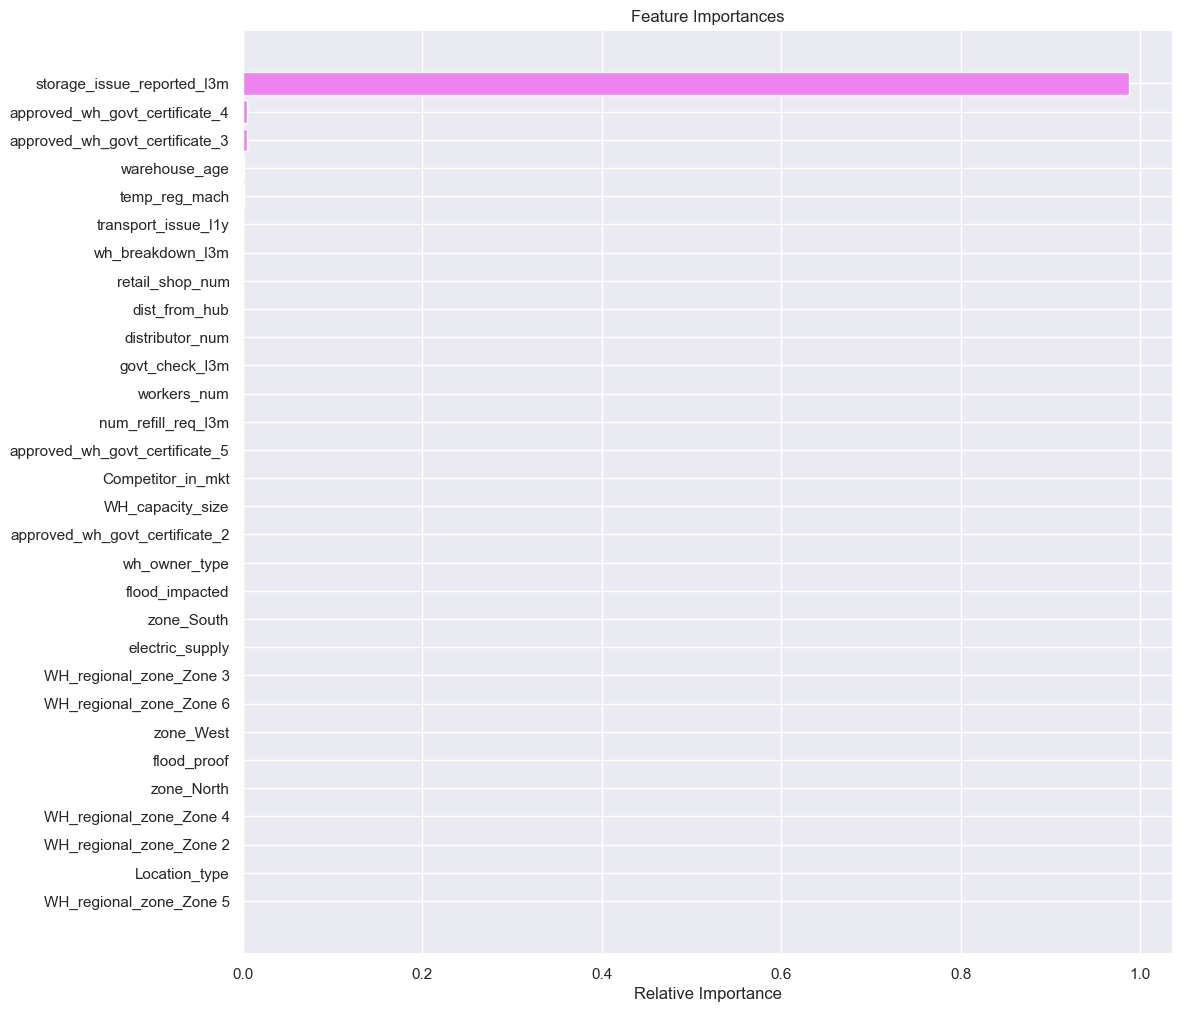

In [420]:
feature_names = X_train.columns
importances = rf_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

## Observed VS Predicted Values Plot of the test data for the best model, i.e., Random Forest Model

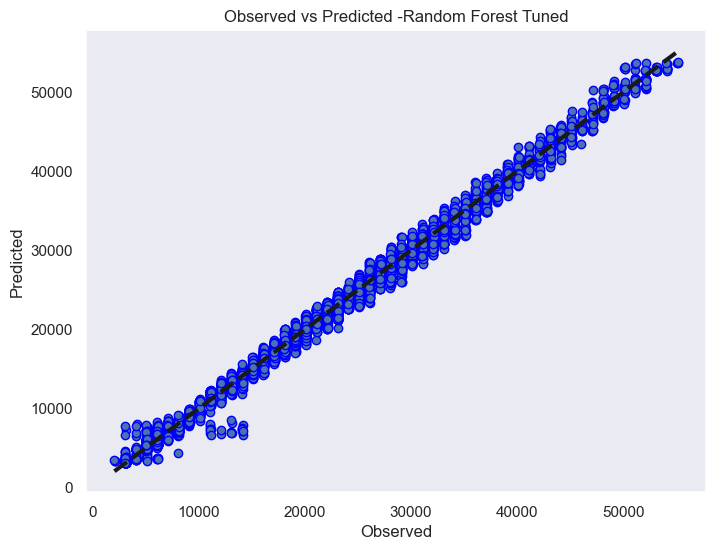

In [422]:
# So plot observed and predicted values of the test data for the best model i.e. gradient boosting model
fig, ax = plt.subplots(figsize=(8, 6))
# y_pred = gb_estimator.predict(X_test)
# y_pred = rf_tuned.predict(X_test)
y_pred = rf_tuned.predict(X_test)

ax.scatter(y_test, y_pred, edgecolors=(0, 0, 1))
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=3)
ax.set_xlabel("Observed")
ax.set_ylabel("Predicted")
ax.set_title("Observed vs Predicted -Random Forest Tuned")
plt.grid()
plt.show()



# **Actionable Insights & Recommendations**

## Insight
● Operational intensity is the primary driver of shipment volume, with recent storage activity emerging as the strongest indicator of demand and throughput requirements.
● Regulatory readiness directly enables higher shipment capacity, as warehouses with stronger government certification consistently support larger product movement.
● Mature warehouses outperform newer facilities, indicating that operational experience and infrastructure readiness play a critical role in meeting demand.
● Advanced ensemble forecasting models deliver high reliability, with the selected Random Forest model achieving approximately 4% prediction error, making it suitable for enterprise-level supply planning.
● Geographic and structural factors are secondary, reinforcing the need to focus on dynamic operational signals rather than static warehouse attributes.


## Business Recommendations
● Adopt predictive shipment planning using the Random Forest model to proactively align supply with warehouse-level demand and reduce inventory mismatches.
● Strengthen operational governance in high-activity warehouses, prioritizing preventive maintenance and storage optimization to support sustained throughput.
● Accelerate compliance upgrades and certification improvements, enabling warehouses to scale shipments efficiently and reduce regulatory constraints.
● Invest selectively in newer or lower-maturity warehouses, focusing on infrastructure, process standardization, and workforce capability development.
● Shift from reactive to data-driven supply chain decisions, using model-based demand insights to guide inventory allocation, production planning, and regional distribution strategies.
Final Recommendation
● Implement the tuned Random Forest model as a decision-support tool to guide warehouse-level shipment planning, reduce inventory mismatch, and enhance overall supply chain efficiency.


___